In [28]:
#!pip install matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Initial Imports, Reading and Cleaning Data

In [29]:
data = pd.read_csv('/home/mayankramchandani/Actigraphy/WELLNESS/data/output_raw gt3x files/SadehResults/output_raw gt3x files/results/part5_daysummary_WW_L40M100V400_Sadeh1994_ZC.csv')

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23441 entries, 0 to 23440
Columns: 194 entries, ID to daytype
dtypes: float64(139), int64(36), object(19)
memory usage: 34.7+ MB
None


In [30]:
columns_to_keep = [
    # Participant & Metadata
    'ID', 'filename', 'calendar_date', 'weekday', 'filename_dir', 'foldername',
    'cleaningcode', 'guider', 'GGIRversion', 'daytype',

    # Sleep & Non-wear Information
    'dur_day_min', 'sleep_efficiency_after_onset', 'nonwear_perc_day',
    'nonwear_perc_spt', 'nonwear_perc_day_spt', 'dur_spt_sleep_min',
    'dur_spt_wake_IN_min', 'dur_spt_wake_LIG_min', 'dur_spt_wake_MOD_min',
    'dur_spt_wake_VIG_min', 'N_atleast5minwakenight', 'tail_expansion_minutes',

    # Psychomotor Activity Variables (Light, Moderate, Vigorous, Inactivity)
    'ACC_day_mg', 'dur_day_total_LIG_min', 'dur_day_total_MOD_min',
    'dur_day_total_VIG_min', 'dur_day_total_IN_min', 'dur_day_IN_unbt_min',
    'dur_day_LIG_unbt_min', 'dur_day_MOD_unbt_min', 'dur_day_VIG_unbt_min',

    # Bouts & Fragments
    'Nbouts_day_LIG_bts_1_5', 'Nbouts_day_LIG_bts_5_10', 'Nbouts_day_LIG_bts_10',
    'Nbouts_day_MVPA_bts_1_5', 'Nbouts_day_MVPA_bts_5_10', 'Nbouts_day_MVPA_bts_10',
    'Nbouts_day_IN_bts_30', 'Nbouts_day_IN_bts_20_30', 'Nbouts_day_IN_bts_10_20',
    'FRAG_Nfrag_PA_day', 'FRAG_mean_dur_PA_day', 'FRAG_Nfrag_LIPA_day',
    'FRAG_mean_dur_LIPA_day', 'FRAG_Nfrag_MVPA_day', 'FRAG_mean_dur_MVPA_day',
    'FRAG_Nfrag_IN_day', 'FRAG_mean_dur_IN_day',

    # Speed & Intensity
    'quantile_mostactive60min_mg', 'quantile_mostactive30min_mg',

    # Energy Variables
    'ACC_day_total_MOD_mg', 'ACC_day_total_VIG_mg', 'ACC_day_total_IN_mg',
    'ACC_day_total_LIG_mg', 'dur_day_MVPA_bts_1_5_min', 'dur_day_MVPA_bts_5_10_min',
    'dur_day_MVPA_bts_10_min', 'ACC_day_MVPA_bts_1_5_mg', 'ACC_day_MVPA_bts_5_10_mg',
    'ACC_day_MVPA_bts_10_mg',

    # Fragmentation Indices
    'FRAG_Gini_dur_IN_day', 'FRAG_Gini_dur_PA_day', 'FRAG_CoV_dur_IN_day',
    'FRAG_CoV_dur_PA_day', 'FRAG_alpha_dur_IN_day', 'FRAG_alpha_dur_PA_day',
    'FRAG_SD_dur_IN_day', 'FRAG_SD_dur_PA_day', 'FRAG_NFragPM_PA_day',
    'FRAG_NFragPM_IN_day', 'FRAG_Nfrag_IN_spt', 'FRAG_Nfrag_PA_spt',

    # Temporal Features (L5/M10)
    'L5TIME', 'L5VALUE', 'M5TIME', 'M5VALUE', 'L10TIME', 'L10VALUE',
    'M10TIME', 'M10VALUE', 'L5TIME_num', 'L10TIME_num', 'M10TIME_num', 'M5TIME_num',

    # Bouts of Inactivity
    'dur_day_IN_bts_30_min', 'dur_day_IN_bts_20_30_min', 'dur_day_IN_bts_10_20_min',

    # Bouts of Light Activity
    'dur_day_LIG_bts_10_min', 'dur_day_LIG_bts_5_10_min', 'dur_day_LIG_bts_1_5_min',
]

In [31]:
cleaned_data = data[columns_to_keep]

cleaned_data = cleaned_data[
    (cleaned_data['cleaningcode'] == 1) &
    (cleaned_data['guider'] == 'HDCZA')
]

output_file = 'temp_files/cleaned_day5_summary.csv'
cleaned_data.to_csv(output_file, index=False)

cleaned_data.head()


,ID,filename,calendar_date,weekday,filename_dir,foldername,cleaningcode,guider,GGIRversion,daytype,...,L5TIME_num,L10TIME_num,M10TIME_num,M5TIME_num,dur_day_IN_bts_30_min,dur_day_IN_bts_20_30_min,dur_day_IN_bts_10_20_min,dur_day_LIG_bts_10_min,dur_day_LIG_bts_5_10_min,dur_day_LIG_bts_1_5_min
0,TAS1E31150217_2016-11-02___09-49-36.gt3x,TAS1E31150217_2016-11-02___09-49-36.gt3x.RData,2016-08-25,Thursday,/data/WELLNESS_actigraph/raw gt3x files/CBN_00...,CBN_00005_002,1.0,HDCZA,3.1.2,WD,...,29.315,25.482,13.149,17.815,276.333,45.917,99.583,0.000,0.000,12.250
1,TAS1E31150217_2016-11-02___09-49-36.gt3x,TAS1E31150217_2016-11-02___09-49-36.gt3x.RData,2016-08-26,Friday,/data/WELLNESS_actigraph/raw gt3x files/CBN_00...,CBN_00005_002,1.0,HDCZA,3.1.2,WD,...,27.182,25.515,13.015,14.849,333.667,44.000,45.333,0.000,0.000,11.083
2,TAS1E31150217_2016-11-02___09-49-36.gt3x,TAS1E31150217_2016-11-02___09-49-36.gt3x.RData,2016-08-27,Saturday,/data/WELLNESS_actigraph/raw gt3x files/CBN_00...,CBN_00005_002,1.0,HDCZA,3.1.2,WE,...,25.432,22.432,12.265,12.932,206.750,21.333,37.417,0.000,5.083,58.500
3,TAS1E31150217_2016-11-02___09-49-36.gt3x,TAS1E31150217_2016-11-02___09-49-36.gt3x.RData,2016-08-28,Sunday,/data/WELLNESS_actigraph/raw gt3x files/CBN_00...,CBN_00005_002,1.0,HDCZA,3.1.2,WE,...,28.332,25.999,12.999,14.999,650.083,0.000,65.333,10.583,10.667,22.917
4,TAS1E31150217_2016-11-02___09-49-36.gt3x,TAS1E31150217_2016-11-02___09-49-36.gt3x.RData,2016-08-29,Monday,/data/WELLNESS_actigraph/raw gt3x files/CBN_00...,CBN_00005_002,1.0,HDCZA,3.1.2,WD,...,28.449,25.782,12.615,12.615,178.167,0.000,0.000,0.000,0.000,53.500


In [32]:
def plot_variable_distribution(df, variable, title, xlabel):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, y=variable)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Value')
    plt.show()

qids_variables = ['qids_sr_1' ,'qids_sr_2' ,'qids_sr_3' ,'qids_sr_4', 'qids_sr_5', 'qids_sr_6', 'qids_sr_7', 'qids_sr_8' , 'qids_sr_9', 'qids_sr_10', 'qids_sr_11', 
                  'qids_sr_12', 'qids_sr_13', 'qids_sr_14','qids_sr_15', 'qids_sr_16',
                  'qidsrtotscore', 'qidsintact', 'qidsnoniatotscore', 'qidsrtot'] # Total score is qidsrtot

energy_activity_variables = [
    # Overall Activity & Energy Expenditure
    'ACC_day_mg', 'ACC_day_total_IN_mg', 'ACC_day_total_LIG_mg',
    'ACC_day_total_MOD_mg', 'ACC_day_total_VIG_mg',

    # Intensity Categories
    'dur_day_total_LIG_min', 'dur_day_total_MOD_min', 'dur_day_total_VIG_min',
    'dur_day_total_IN_min',

    # Temporal Features (L5/M10)
    'L5VALUE', 'M5VALUE', 'L10VALUE', 'M10VALUE'
    #, 'L5TIME_num', 'L10TIME_num', 'M10TIME_num', 'M5TIME_num'
]

In [33]:
cleaned_data

,ID,filename,calendar_date,weekday,filename_dir,foldername,cleaningcode,guider,GGIRversion,daytype,...,L5TIME_num,L10TIME_num,M10TIME_num,M5TIME_num,dur_day_IN_bts_30_min,dur_day_IN_bts_20_30_min,dur_day_IN_bts_10_20_min,dur_day_LIG_bts_10_min,dur_day_LIG_bts_5_10_min,dur_day_LIG_bts_1_5_min
0,TAS1E31150217_2016-11-02___09-49-36.gt3x,TAS1E31150217_2016-11-02___09-49-36.gt3x.RData,2016-08-25,Thursday,/data/WELLNESS_actigraph/raw gt3x files/CBN_00...,CBN_00005_002,1.0,HDCZA,3.1.2,WD,...,29.315,25.482,13.149,17.815,276.333,45.917,99.583,0.000,0.000,12.250
1,TAS1E31150217_2016-11-02___09-49-36.gt3x,TAS1E31150217_2016-11-02___09-49-36.gt3x.RData,2016-08-26,Friday,/data/WELLNESS_actigraph/raw gt3x files/CBN_00...,CBN_00005_002,1.0,HDCZA,3.1.2,WD,...,27.182,25.515,13.015,14.849,333.667,44.000,45.333,0.000,0.000,11.083
2,TAS1E31150217_2016-11-02___09-49-36.gt3x,TAS1E31150217_2016-11-02___09-49-36.gt3x.RData,2016-08-27,Saturday,/data/WELLNESS_actigraph/raw gt3x files/CBN_00...,CBN_00005_002,1.0,HDCZA,3.1.2,WE,...,25.432,22.432,12.265,12.932,206.750,21.333,37.417,0.000,5.083,58.500
3,TAS1E31150217_2016-11-02___09-49-36.gt3x,TAS1E31150217_2016-11-02___09-49-36.gt3x.RData,2016-08-28,Sunday,/data/WELLNESS_actigraph/raw gt3x files/CBN_00...,CBN_00005_002,1.0,HDCZA,3.1.2,WE,...,28.332,25.999,12.999,14.999,650.083,0.000,65.333,10.583,10.667,22.917
4,TAS1E31150217_2016-11-02___09-49-36.gt3x,TAS1E31150217_2016-11-02___09-49-36.gt3x.RData,2016-08-29,Monday,/data/WELLNESS_actigraph/raw gt3x files/CBN_00...,CBN_00005_002,1.0,HDCZA,3.1.2,WD,...,28.449,25.782,12.615,12.615,178.167,0.000,0.000,0.000,0.000,53.500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23429,TAS1F39160186_2018-11-28___13-43-04.gt3x,TAS1F39160186_2018-11-28___13-43-04.gt3x.RData,2018-11-22,Thursday,/data/WELLNESS_actigraph/raw gt3x files/CBN_00...,CBN_00001_003,1.0,HDCZA,3.1.2,WD,...,32.500,27.167,19.167,21.667,599.250,25.250,25.250,0.000,0.000,2.000
23430,TAS1F39160186_2018-11-28___13-43-04.gt3x,TAS1F39160186_2018-11-28___13-43-04.gt3x.RData,2018-11-23,Friday,/data/WELLNESS_actigraph/raw gt3x files/CBN_00...,CBN_00001_003,1.0,HDCZA,3.1.2,WD,...,32.215,32.215,18.382,15.882,631.583,46.833,67.667,0.000,0.000,18.500
23431,TAS1F39160186_2018-11-28___13-43-04.gt3x,TAS1F39160186_2018-11-28___13-43-04.gt3x.RData,2018-11-25,Sunday,/data/WELLNESS_actigraph/raw gt3x files/CBN_00...,CBN_00001_003,1.0,HDCZA,3.1.2,WE,...,32.349,31.349,20.182,20.682,1921.167,0.000,0.000,0.000,5.917,20.500
23432,TAS1F39160186_2018-11-28___13-43-04.gt3x,TAS1F39160186_2018-11-28___13-43-04.gt3x.RData,2018-11-26,Monday,/data/WELLNESS_actigraph/raw gt3x files/CBN_00...,CBN_00001_003,1.0,HDCZA,3.1.2,WD,...,29.399,27.899,14.065,19.065,604.583,50.000,29.750,0.000,0.000,24.500


## Total Days Recorded

Lowest days per participant: 4
Maximum day per participant: 707
Total Participants: 96
Total Days Recorded: 22249
Average Days Recorded per Participant (before filtering): 231.76
Standard Deviation of Days Recorded per Participant (before filtering): 170.02
Total Days Recorded After Filtering: 22249
Data Loss (number of days): 0
Average Valid Days per Participant (after filtering): 231.76


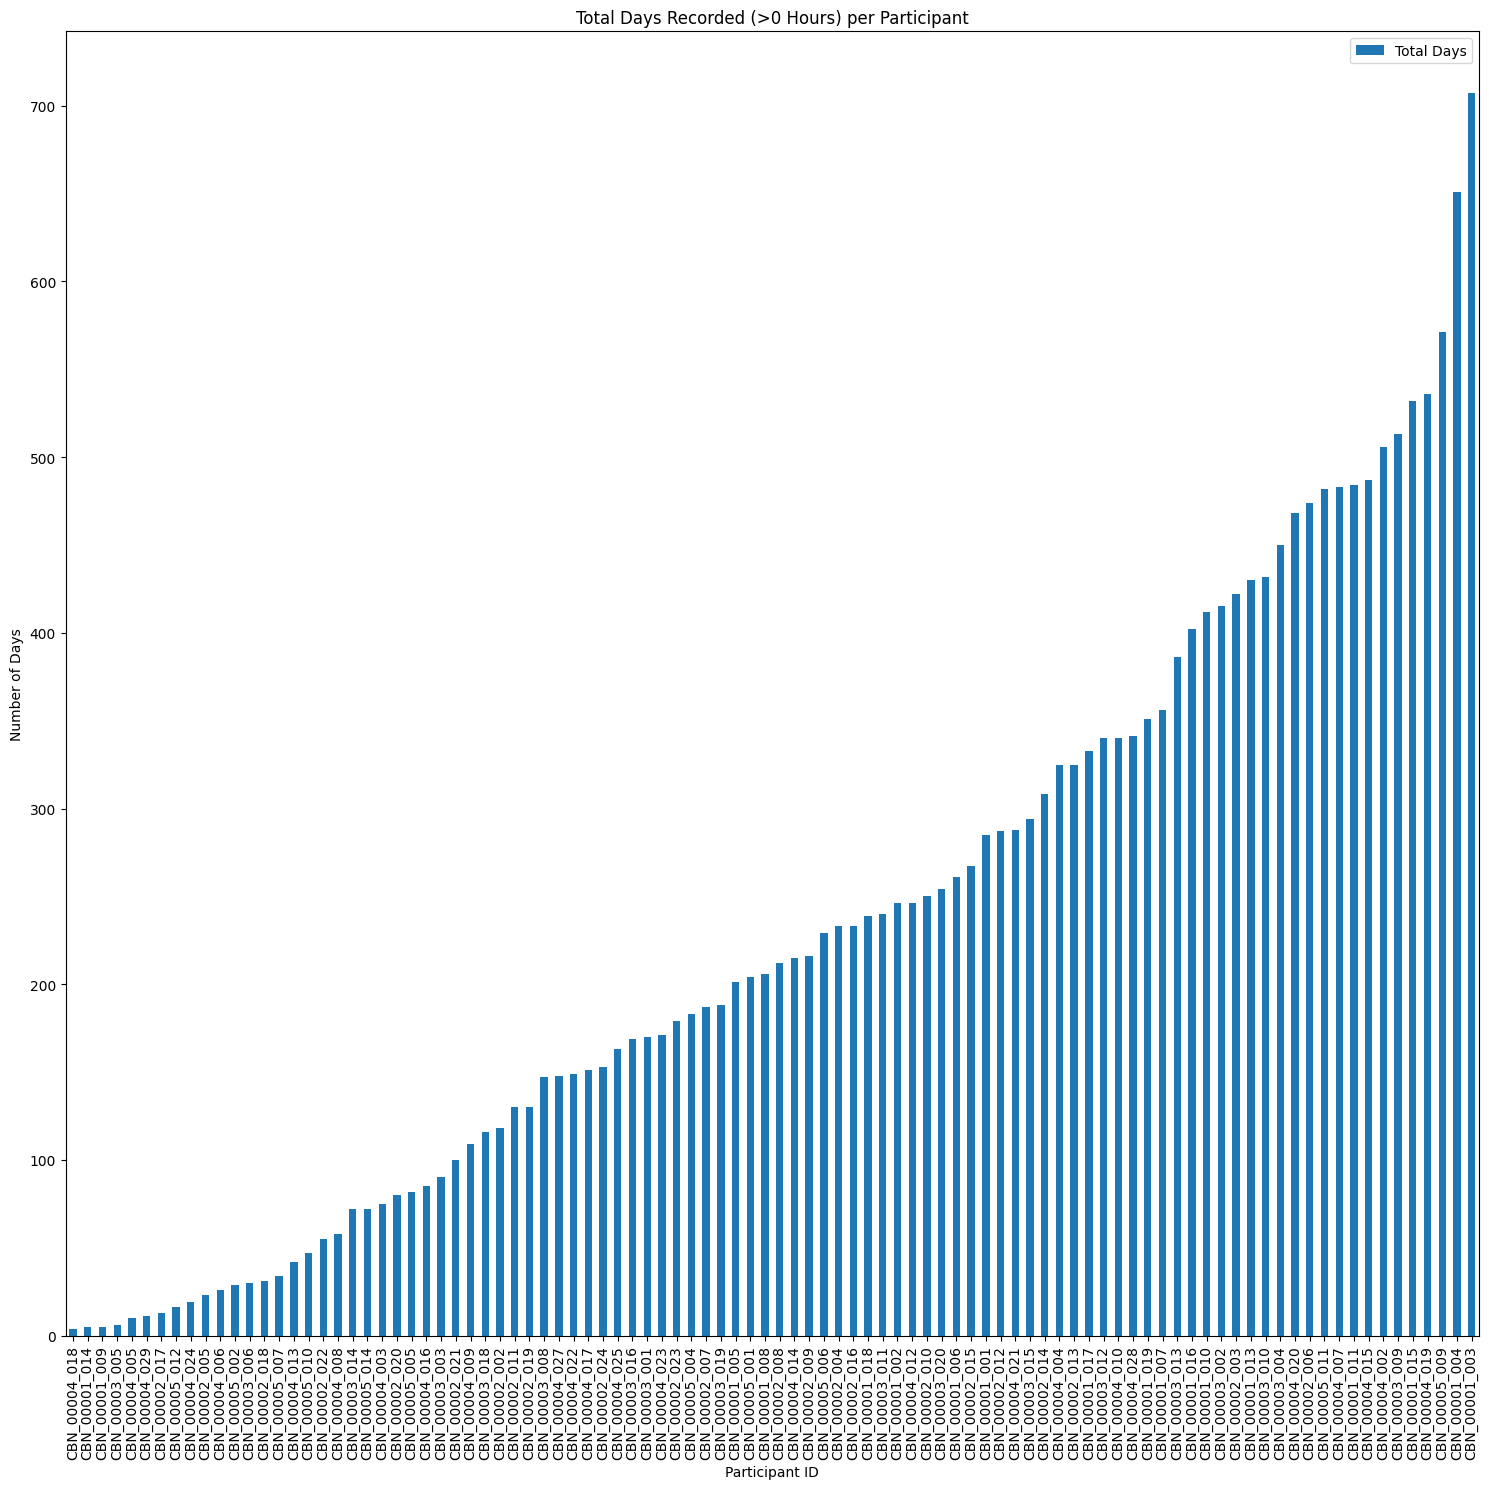

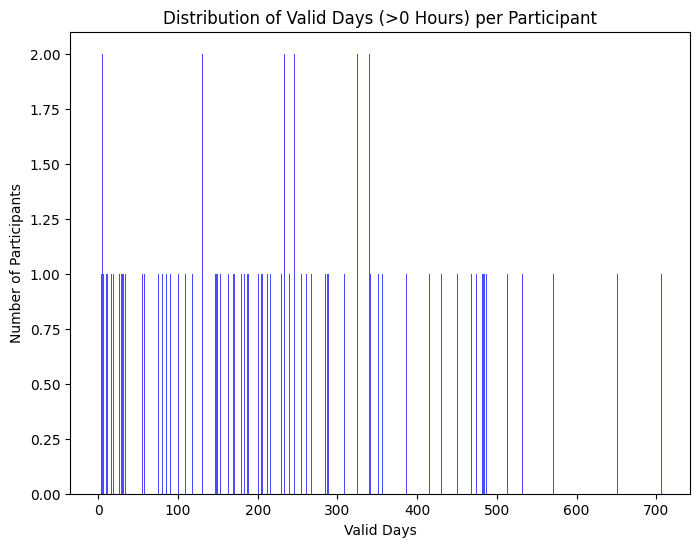

In [34]:
actigraphy_data = cleaned_data 

total_participants = actigraphy_data['foldername'].nunique()
total_days_recorded = len(actigraphy_data)
days_per_participant = actigraphy_data.groupby('foldername').size()

print(f"Lowest days per participant: {days_per_participant.min()}")
print(f"Maximum day per participant: {days_per_participant.max()}")

# Calculate average days per participant before filtering
average_days_per_participant = days_per_participant.mean()
std_days_per_participant = days_per_participant.std()

print(f"Total Participants: {total_participants}")
print(f"Total Days Recorded: {total_days_recorded}")
print(f"Average Days Recorded per Participant (before filtering): {average_days_per_participant:.2f}")
print(f"Standard Deviation of Days Recorded per Participant (before filtering): {std_days_per_participant:.2f}")

# Filtering based on 10-hour minimum valid hours per day
valid_days = total_days_recorded
valid_days_per_participant = cleaned_data.groupby('foldername').size()

# Calculate data loss
# Can calculate data loss by looking at how many participants and days were originally there
filtered_total_days = valid_days
data_loss = total_days_recorded - filtered_total_days
average_valid_days_per_participant = valid_days_per_participant.mean()

print(f"Total Days Recorded After Filtering: {filtered_total_days}")
print(f"Data Loss (number of days): {data_loss}")
print(f"Average Valid Days per Participant (after filtering): {average_valid_days_per_participant:.2f}")

summary_df = pd.DataFrame({
    "Total Days": days_per_participant}).fillna(0)  # Fill NA with 0 for participants with no valid days

plt.figure(figsize=(15, 15))

summary_df.sort_values(by='Total Days', inplace=True)

summary_df.plot(kind="bar", stacked=False, ax=plt.gca())
plt.title("Total Days Recorded (>0 Hours) per Participant")
plt.xlabel("Participant ID")
plt.ylabel("Number of Days")
plt.legend(["Total Days", "Valid Days (0+ Hours)"])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(valid_days_per_participant, bins=range(0, int(valid_days_per_participant.max()) + 1, 1), alpha=0.7, color='blue')
plt.title("Distribution of Valid Days (>0 Hours) per Participant")
plt.xlabel("Valid Days")
plt.ylabel("Number of Participants")
plt.show()


## Light and Temperature

In [35]:
temps_all = pd.read_csv("/home/mayankramchandani/Actigraphy/WELLNESS/All_temps.csv")
actigraphy_df = actigraphy_data

# Filter to include only the sites needed
valid_stations = ["TORONTO CITY", "HAMILTON A", "CALGARY INTL A", "VANCOUVER INTL A", "KINGSTON CLIMATE"]
temps_all = temps_all[temps_all['STATION_NAME'].isin(valid_stations)]

# --- Helper function to extract site from foldername ---
def get_site_from_folder(folder):
    # Check for a unique code in the folder string
    folder_str = str(folder)
    if "00001" in folder:
        return "Toronto"
    elif "00002" in folder:
        return "Vancouver"
    elif "00003" in folder:
        return "Calgary"
    elif "00004" in folder:
        return "Hamilton"
    elif "00005" in folder:
        return "Kingston"
    else:
        return "Unknown"

# --- Load Actigraphy Data ---
actigraphy_df['calendar_date'] = pd.to_datetime(actigraphy_df['calendar_date'], errors='coerce')
actigraphy_df['foldername'] = actigraphy_df['foldername'].astype(str)
# Assign site based on foldername (e.g., "CBN_00005_002" will return "Kingston")
actigraphy_df['site'] = actigraphy_df['foldername'].apply(get_site_from_folder)
# Extract month and day from calendar_date
actigraphy_df['month'] = actigraphy_df['calendar_date'].dt.month
actigraphy_df['day'] = actigraphy_df['calendar_date'].dt.day
actigraphy_df['calendar_date'] = pd.to_datetime(actigraphy_df['calendar_date']).dt.date
# Map the STATION_NAME values to simpler site labels:
temp_site_map = {
    "TORONTO CITY": "Toronto",
    "VANCOUVER INTL A": "Vancouver",
    "CALGARY INTL A": "Calgary",
    "HAMILTON A": "Hamilton",
    "KINGSTON CLIMATE": "Kingston"
}
temps_all['site'] = temps_all['STATION_NAME'].map(temp_site_map)
temps_all['date'] = pd.to_datetime(temps_all['LOCAL_DATE']).dt.date

# Group by site and date to get the mean temperature for each day at each site
temp_mean = temps_all.groupby(['site', 'date'])['MEAN_TEMPERATURE'].mean().reset_index()

# --- Light Data ---
# Load light CSVs for Calgary, Ontario, and Vancouver
calgary_light = pd.read_csv("/home/mayankramchandani/Actigraphy/WELLNESS/temp_light_data/Calgary_light.csv")
toronto_light = pd.read_csv("/home/mayankramchandani/Actigraphy/WELLNESS/temp_light_data/Toronto_light.csv")
kingston_light = pd.read_csv("/home/mayankramchandani/Actigraphy/WELLNESS/temp_light_data/Kingston_light.csv")
hamilton_light = pd.read_csv("/home/mayankramchandani/Actigraphy/WELLNESS/temp_light_data/Hamilton_light.csv")
van_light = pd.read_csv("/home/mayankramchandani/Actigraphy/WELLNESS/temp_light_data/Van_light.csv")

# For Calgary and Vancouver, assign the site manually:
calgary_light['site'] = "Calgary"
van_light['site'] = "Vancouver"
toronto_light['site'] = "Toronto"
kingston_light['site'] = "Kingston"
hamilton_light['site'] = "Hamilton"

# Ensure each light DataFrame has a proper date, month, and day column.
for df in [calgary_light, toronto_light, kingston_light, hamilton_light, van_light]:
    df['date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day

# Combine the light data
light_all = pd.concat([calgary_light, toronto_light, kingston_light, hamilton_light, van_light], ignore_index=True)
# Aggregate to compute the total daylight per day (assuming there is a column named 'daylight')
light_summary = light_all.groupby(['site', 'month', 'day'])['Hours of illumination (day)'].sum().reset_index()

# --- Merge Temperature and Light Data with Actigraphy Data ---
# Merge temperature data on site and exact date (calendar_date matches date)
merged_df = actigraphy_df.merge(temp_mean, left_on=['site', 'calendar_date'], 
                                  right_on=['site', 'date'], how='left')
# Merge light data on site, month, and day
merged_df = merged_df.merge(light_summary, on=['site', 'month', 'day'], how='left')

# Now, merged_df contains the actigraphy data along with the mean temperature for that day and the total daylight.
print(merged_df)
merged_df.to_csv("temp_files/Actigraphy_Part5_Light_Temperature.csv")

                                             ID  \
0      TAS1E31150217_2016-11-02___09-49-36.gt3x   
1      TAS1E31150217_2016-11-02___09-49-36.gt3x   
2      TAS1E31150217_2016-11-02___09-49-36.gt3x   
3      TAS1E31150217_2016-11-02___09-49-36.gt3x   
4      TAS1E31150217_2016-11-02___09-49-36.gt3x   
...                                         ...   
22244  TAS1F39160186_2018-11-28___13-43-04.gt3x   
22245  TAS1F39160186_2018-11-28___13-43-04.gt3x   
22246  TAS1F39160186_2018-11-28___13-43-04.gt3x   
22247  TAS1F39160186_2018-11-28___13-43-04.gt3x   
22248  TAS1F39160186_2018-11-28___13-43-04.gt3x   

                                             filename calendar_date   weekday  \
0      TAS1E31150217_2016-11-02___09-49-36.gt3x.RData    2016-08-25  Thursday   
1      TAS1E31150217_2016-11-02___09-49-36.gt3x.RData    2016-08-26    Friday   
2      TAS1E31150217_2016-11-02___09-49-36.gt3x.RData    2016-08-27  Saturday   
3      TAS1E31150217_2016-11-02___09-49-36.gt3x.RData    2016-0

In [36]:
df = pd.read_csv("temp_files/Actigraphy_Part5_Light_Temperature.csv")
df.columns

Index(['Unnamed: 0', 'ID', 'filename', 'calendar_date', 'weekday',
       'filename_dir', 'foldername', 'cleaningcode', 'guider', 'GGIRversion',
       'daytype', 'dur_day_min', 'sleep_efficiency_after_onset',
       'nonwear_perc_day', 'nonwear_perc_spt', 'nonwear_perc_day_spt',
       'dur_spt_sleep_min', 'dur_spt_wake_IN_min', 'dur_spt_wake_LIG_min',
       'dur_spt_wake_MOD_min', 'dur_spt_wake_VIG_min',
       'N_atleast5minwakenight', 'tail_expansion_minutes', 'ACC_day_mg',
       'dur_day_total_LIG_min', 'dur_day_total_MOD_min',
       'dur_day_total_VIG_min', 'dur_day_total_IN_min', 'dur_day_IN_unbt_min',
       'dur_day_LIG_unbt_min', 'dur_day_MOD_unbt_min', 'dur_day_VIG_unbt_min',
       'Nbouts_day_LIG_bts_1_5', 'Nbouts_day_LIG_bts_5_10',
       'Nbouts_day_LIG_bts_10', 'Nbouts_day_MVPA_bts_1_5',
       'Nbouts_day_MVPA_bts_5_10', 'Nbouts_day_MVPA_bts_10',
       'Nbouts_day_IN_bts_30', 'Nbouts_day_IN_bts_20_30',
       'Nbouts_day_IN_bts_10_20', 'FRAG_Nfrag_PA_day', 'FRAG_me

# QIDS Actigraphy Pairings

In [ ]:
import pandas as pd
from datetime import timedelta
import numpy as np

qids_df = pd.read_stata("/data/deonj3/wellqids.dta")
qids_df.to_csv("temp_files/qids_data.csv")
print("Columns in qids_df:", qids_df.columns)

qids_id_column   = qids_df.columns[1]      # subject_id
qids_date_column = qids_df.columns[37]     # qsdtc

qids_df["subj"] = qids_df[qids_id_column].astype(str)
qids_df["date"] = pd.to_datetime(
    qids_df[qids_date_column],
    format="%Y-%m-%dT%H:%M:%S",
    errors="coerce"
)

for var in qids_variables:
    qids_df[var] = qids_df[var].astype(str).str.replace("\n", " ").str.strip()
    qids_df[var] = pd.to_numeric(qids_df[var], errors="coerce")

qids_df_subset = qids_df[["subj", "date"] + qids_variables].dropna(subset=["date"])
qids_df_subset["row_idx"] = qids_df_subset.groupby("subj").cumcount()
qids_df_subset = qids_df_subset[qids_df_subset["row_idx"] % 2 == 0].drop(columns=["row_idx"])

actigraphy_df = pd.read_csv("temp_files/Actigraphy_Part5_Light_Temperature.csv")

actigraphy_df["calendar_date"] = pd.to_datetime(actigraphy_df["calendar_date"], errors="coerce")
actigraphy_df["foldername"] = actigraphy_df["foldername"].astype(str)

actigraphy_df["relative_amplitude"] = (
    actigraphy_df["M10VALUE"] - actigraphy_df["L5VALUE"]
) / (actigraphy_df["M10VALUE"] + actigraphy_df["L5VALUE"])

def circ_diff(x):
    if pd.isna(x):
        return np.nan
    if x > 12:
        return x - 24
    if x < -12:
        return x + 24
    return x

energy_activity_variables = [
    "relative_amplitude",
    "MEAN_TEMPERATURE",
    "Hours of illumination (day)"
]

records = []

for subj, q_sub in qids_df_subset.groupby("subj"):
    a_sub = actigraphy_df[actigraphy_df["foldername"] == subj].dropna(subset=["calendar_date"])
    if a_sub.empty:
        continue

    a_sub = a_sub.copy()
    a_sub["calendar_date"] = pd.to_datetime(a_sub["calendar_date"], errors="coerce").dt.normalize()

    q_sub = q_sub.copy()
    q_sub["date"] = pd.to_datetime(q_sub["date"], errors="coerce").dt.normalize()
    q_sub = q_sub.rename(columns={"date": "qids_date"})

    merged = pd.merge_asof(
        a_sub.sort_values("calendar_date"),
        q_sub.sort_values("qids_date"),
        left_on="calendar_date",
        right_on="qids_date",
        direction="nearest",
        suffixes=("", "_qids"),
    )

    merged["calendar_date"] = pd.to_datetime(merged["calendar_date"], errors="coerce")
    merged["qids_date"] = pd.to_datetime(merged["qids_date"], errors="coerce")

    merged["day_diff"] = (merged["calendar_date"] - merged["qids_date"]).dt.days.abs()
    merged = merged[merged["day_diff"] <= 5]

    if merged.empty:
        continue

    # --- NEW: CPD from MSF (here using L5TIME_num) ---
    def compute_cpd_msf_window(g):
        g = g.sort_values("calendar_date")
        msf = g["L5TIME_num"].astype(float)
        msf = msf.dropna()
        if len(msf) == 0:
            return np.nan
        mean_msf = msf.mean()
        lag_msf = msf.shift(1)

        dev_mean = msf - mean_msf
        dev_lag  = msf - lag_msf

        dev_mean_adj = dev_mean.apply(circ_diff)
        dev_lag_adj  = dev_lag.apply(circ_diff)

        cpd_day = np.sqrt(dev_mean_adj**2 + dev_lag_adj**2)
        return np.nanmean(cpd_day)

    cpd_window = (
        merged.groupby(["subj", "qids_date"])
        .apply(compute_cpd_msf_window)
        .reset_index(name="CPD")   # or "CPD_L5" if preferred
    )
    # -----------------------------------------------

    agg_dict = {v: "mean" for v in energy_activity_variables}
    agg_dict.update({v: "first" for v in qids_variables})

    grouped = merged.groupby(["subj", "qids_date"]).agg(agg_dict).reset_index()

    grouped = grouped.merge(cpd_window, on=["subj", "qids_date"], how="left")

    grouped = grouped.rename(columns={"subj": "qids_id"})

    records.append(grouped)

if records:
    summary_df = pd.concat(records, ignore_index=True)
    out_path = "temp_files/11_days_actigraphy_part5_qids_MSFCPD.csv"
    summary_df.to_csv(out_path, index=False)
    print(f"Saved QIDS–actigraphy summary with MSF-based CPD to '{out_path}'.")
else:
    print("No QIDS–actigraphy windows (±5 days) could be formed.")


Columns in qids_df: Index(['visit', 'subject_id', 'year', 'month', 'day', 'score1', 'qids_sr_1',
       'score2', 'qids_sr_2', 'score3', 'qids_sr_3', 'score4', 'qids_sr_4',
       'score5', 'qids_sr_5', 'score6', 'qids_sr_6', 'score7', 'qids_sr_7',
       'score8', 'qids_sr_8', 'score9', 'qids_sr_9', 'score10', 'qids_sr_10',
       'score11', 'qids_sr_11', 'score12', 'qids_sr_12', 'score13',
       'qids_sr_13', 'score14', 'qids_sr_14', 'score15', 'qids_sr_15',
       'score16', 'qids_sr_16', 'qsdtc', 'smdsd', 'scntr', 'svwsf', 'ssuic',
       'sintr', 'sengy', 'spmot', 'ssleep', 'sapet', 'qidsrtotscore',
       'qidsrtot', 'qidsintacttotscore', 'qidsintact', 'qidsnoniatotscore',
       'qidsnonia', 'qidsaord', 'qidsatot', 'last'],
      dtype='object')


/tmp/ipykernel_2215432/81410835.py:100: RuntimeWarning: Mean of empty slice
  return np.nanmean(cpd_day)
/tmp/ipykernel_2215432/81410835.py:100: RuntimeWarning: Mean of empty slice
  return np.nanmean(cpd_day)
/tmp/ipykernel_2215432/81410835.py:100: RuntimeWarning: Mean of empty slice
  return np.nanmean(cpd_day)
/tmp/ipykernel_2215432/81410835.py:100: RuntimeWarning: Mean of empty slice
  return np.nanmean(cpd_day)
/tmp/ipykernel_2215432/81410835.py:100: RuntimeWarning: Mean of empty slice
  return np.nanmean(cpd_day)
/tmp/ipykernel_2215432/81410835.py:104: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_cpd_msf_window)
/tmp/ipykernel_2215432/81410835.py:104: DeprecationWarning: Dat

Saved QIDS–actigraphy summary with MSF-based CPD to 'temp_files/11_days_actigraphy_part5_qids_MSFCPD.csv'.


/tmp/ipykernel_2215432/81410835.py:104: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_cpd_msf_window)
/tmp/ipykernel_2215432/81410835.py:100: RuntimeWarning: Mean of empty slice
  return np.nanmean(cpd_day)
/tmp/ipykernel_2215432/81410835.py:104: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_cpd_msf_window)


site
Toronto      6106
Hamilton     5456
Vancouver    4426
Calgary      4312
Kingston     1949
Name: count, dtype: int64


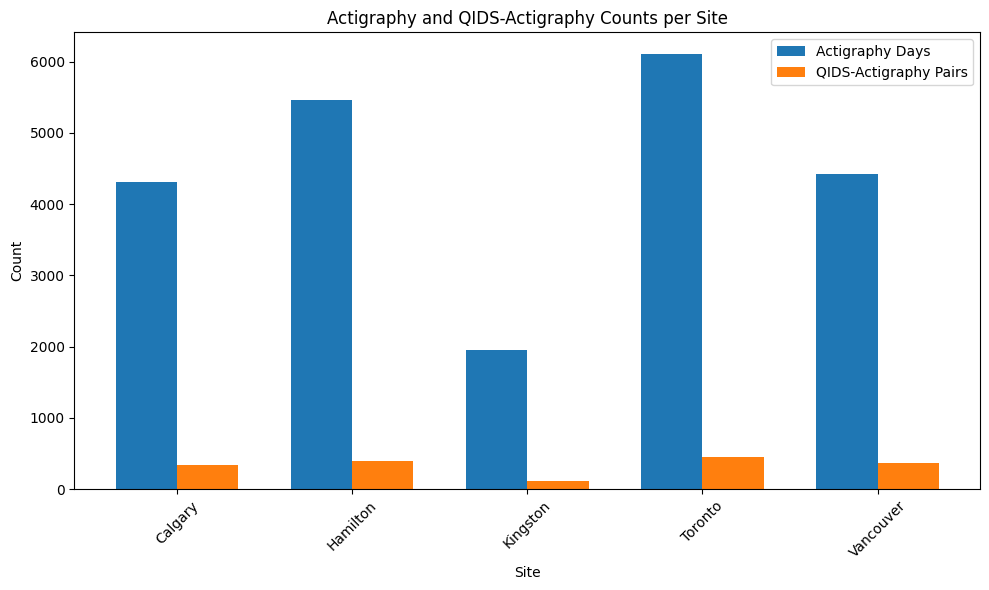

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load merged CSV
merged_df = pd.read_csv("temp_files/Actigraphy_Part5_Light_Temperature.csv")

# Count the number of rows per site
site_actigraphy_counts = merged_df['site'].value_counts()
print(site_actigraphy_counts)

qids_df = pd.read_csv("temp_files/11_days_actigraphy_part5_qids_MSFCPD.csv")

# Group by qids_id and qids_date to count records per pair, then sum counts per participant
grouped_qids = qids_df.groupby(['qids_id', 'qids_date']).size().reset_index(name='record_count')
participant_qids_counts = grouped_qids.groupby('qids_id')['record_count'].sum()  # Series indexed by qids_id

# ---- Merge qids Counts with Site Information ----
# Extract a mapping from participant ID to site from merged_df.
site_info = merged_df[['foldername', 'site']].drop_duplicates().set_index('foldername')

# Convert the participant-level counts to a DataFrame and merge with site info
participant_qids_counts_df = participant_qids_counts.to_frame(name='qids_record_count')
participant_qids_counts_df = participant_qids_counts_df.merge(site_info,
                                                                  left_index=True,
                                                                  right_index=True,
                                                                  how='left')

# Group by site to get the total number of qids-actigraphy pairs per site.
site_qids_counts = participant_qids_counts_df.groupby('site')['qids_record_count'].sum()

# ---- Combine Data for Plotting ----
# Get a combined list of sites (to cover all sites that appear in both datasets)
sites = sorted(set(site_actigraphy_counts.index))

# Reindex both Series to ensure the same order (filling missing sites with 0 count)
actigraphy = site_actigraphy_counts.reindex(sites, fill_value=0)
qids_actigraphy = site_qids_counts.reindex(sites, fill_value=0)

# ---- Create a Grouped Bar Chart ----
x = np.arange(len(sites))  # x-axis positions for sites
width = 0.35  # Width of the bars

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, actigraphy, width, label='Actigraphy Days')
plt.bar(x + width/2, qids_actigraphy, width, label='QIDS-Actigraphy Pairs')

plt.xlabel('Site')
plt.ylabel('Count')
plt.title('Actigraphy and QIDS-Actigraphy Counts per Site')
plt.xticks(x, sites, rotation=45)
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


Total counts is :  1644
Number of unique QIDS IDs: 95
Average QIDS-Actigraphy pairings per participant: 17.31
Standard Deviation of QIDS-Actigraphy pairings per participant: 11.81
Maximum number of pairings of QIDS-Actigraphy pairings per participant: 46.00
Minimum number of pairings of QIDS-Actigraphy pairings per participant: 1.00


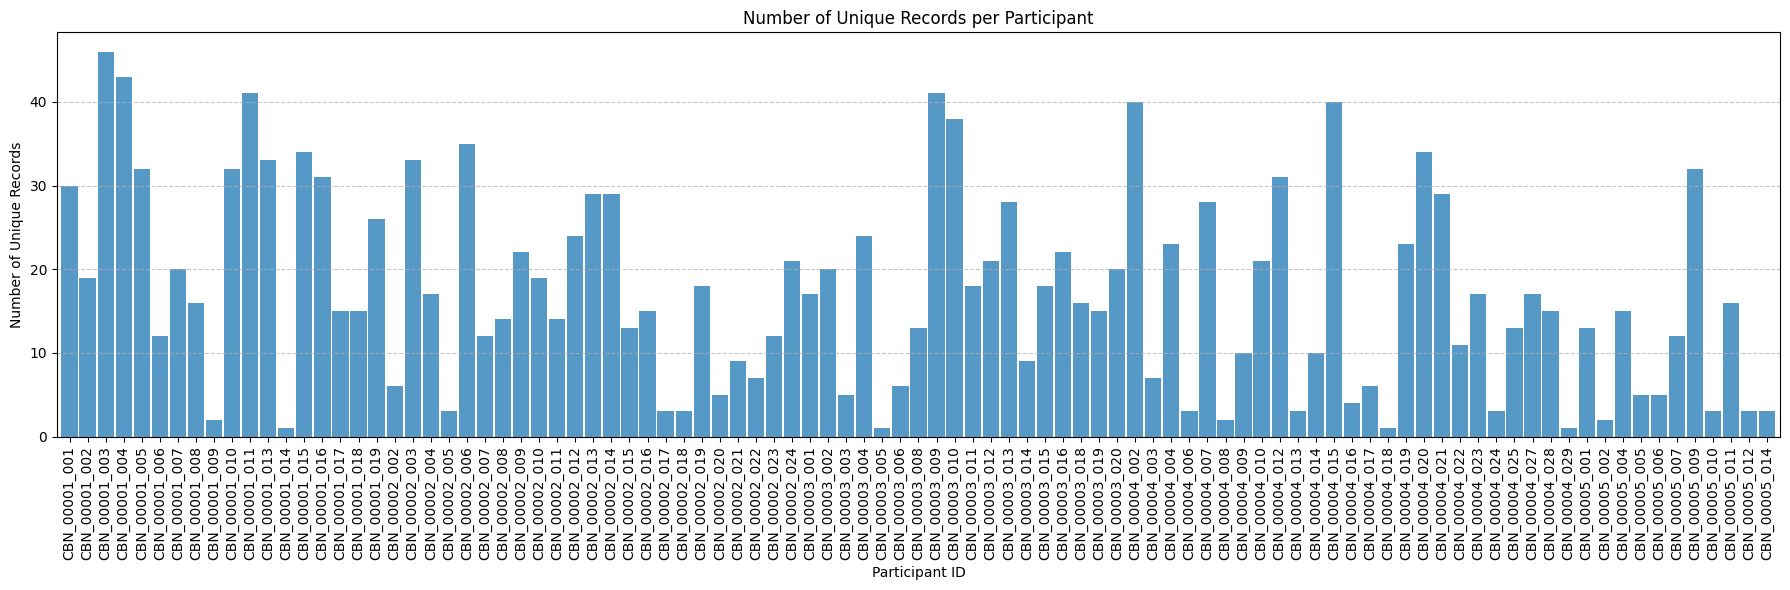

In [54]:
# Group by 'qids_id' and 'qids_date' and count the unique records
actigraphy_data = summary_df
grouped_data = actigraphy_data.groupby(['qids_id', 'qids_date']).size().reset_index(name='record_count')

# Count the number of unique records per participant
participant_counts = grouped_data.groupby('qids_id')['record_count'].sum()
unique_ids = grouped_data['qids_id'].nunique()

print("Total counts is : ", len(grouped_data))

# Calculate average and standard deviation of unique records per participant
avg_per_participant = participant_counts.mean()
std_per_participant = participant_counts.std()

print(f"Number of unique QIDS IDs: {unique_ids}")
print(f"Average QIDS-Actigraphy pairings per participant: {avg_per_participant:.2f}")
print(f"Standard Deviation of QIDS-Actigraphy pairings per participant: {std_per_participant:.2f}")

print(f"Maximum number of pairings of QIDS-Actigraphy pairings per participant: {participant_counts.max():.2f}")
print(f"Minimum number of pairings of QIDS-Actigraphy pairings per participant: {participant_counts.min():.2f}")

# Plot the distribution of unique records per participant
plt.figure(figsize=(18, 6))
participant_counts.sort_index().plot(kind='bar', width=0.9, alpha=0.75)
plt.title("Number of Unique Records per Participant")
plt.xlabel("Participant ID")
plt.ylabel("Number of Unique Records")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [40]:
# Create a mapping dictionary for QIDS-SR variables
column_mapping = {
    "qids_sr_1": "Sleep_onset_Insomnia",
    "qids_sr_2": "Mid_nocturnal_Insomnia",
    "qids_sr_3": "Early_morning_Insomnia",
    "qids_sr_4": "Hypersomnia",
    "qids_sr_5": "Sadness",
    "qids_sr_6": "Decreased_Appetite",
    "qids_sr_7": "Increased_Appetite",
    "qids_sr_8": "Weight_Loss",
    "qids_sr_9": "Weight_Gain",
    "qids_sr_10": "Concentration",
    "qids_sr_11": "Self_worth",
    "qids_sr_12": "Suicidal_Ideation",
    "qids_sr_13": "Interest",
    "qids_sr_14": "Energy",
    "qids_sr_15": "Psychomotor_Retardation",
    "qids_sr_16": "Psychomotor_Agitation",
    "qidsrtot": "Total_QIDS_Score",
    "qidsintact": "Intact_Symptoms",
    "qidsnoniatotscore": "Non_Intact_Symptoms"
}

# Create a function to rename columns dynamically based on the mapping
def rename_columns(df, mapping):
    new_column_names = {}
    for col in df.columns:
        base_name = col.split(" ")[0]  # Extract the variable name before "Correlation" or other suffixes
        if base_name in mapping:
            # Replace the base name and keep suffix intact (e.g., Correlation, p-value, Significant)
            new_column_names[col] = col.replace(base_name, mapping[base_name])
    return df.rename(columns=new_column_names)

# Apply the renaming function to DataFrame
data = rename_columns(data, column_mapping)

# Display the updated DataFrame
print(data.head())


                                         ID  \
0  TAS1E31150217_2016-11-02___09-49-36.gt3x   
1  TAS1E31150217_2016-11-02___09-49-36.gt3x   
2  TAS1E31150217_2016-11-02___09-49-36.gt3x   
3  TAS1E31150217_2016-11-02___09-49-36.gt3x   
4  TAS1E31150217_2016-11-02___09-49-36.gt3x   

                                         filename   weekday calendar_date  \
0  TAS1E31150217_2016-11-02___09-49-36.gt3x.RData  Thursday    2016-08-25   
1  TAS1E31150217_2016-11-02___09-49-36.gt3x.RData    Friday    2016-08-26   
2  TAS1E31150217_2016-11-02___09-49-36.gt3x.RData  Saturday    2016-08-27   
3  TAS1E31150217_2016-11-02___09-49-36.gt3x.RData    Sunday    2016-08-28   
4  TAS1E31150217_2016-11-02___09-49-36.gt3x.RData    Monday    2016-08-29   

   window_number   start_end_window  sleeponset sleeponset_ts  wakeup  \
0              1  13:08:55-11:40:50      28.967      04:58:00  35.682   
1              2  11:40:55-12:15:50      25.117      01:07:00  36.265   
2              3  12:15:55-08:59:50

In [41]:
print(data)

                                             ID  \
0      TAS1E31150217_2016-11-02___09-49-36.gt3x   
1      TAS1E31150217_2016-11-02___09-49-36.gt3x   
2      TAS1E31150217_2016-11-02___09-49-36.gt3x   
3      TAS1E31150217_2016-11-02___09-49-36.gt3x   
4      TAS1E31150217_2016-11-02___09-49-36.gt3x   
...                                         ...   
23436  TAS1F39160190_2018-09-13___10-03-17.gt3x   
23437  TAS1F39160190_2018-09-13___10-03-17.gt3x   
23438  TAS1F39160190_2018-09-13___10-03-17.gt3x   
23439  TAS1F39160190_2018-10-30___10-56-50.gt3x   
23440  TAS1F39160190_2018-10-30___10-56-50.gt3x   

                                             filename   weekday calendar_date  \
0      TAS1E31150217_2016-11-02___09-49-36.gt3x.RData  Thursday    2016-08-25   
1      TAS1E31150217_2016-11-02___09-49-36.gt3x.RData    Friday    2016-08-26   
2      TAS1E31150217_2016-11-02___09-49-36.gt3x.RData  Saturday    2016-08-27   
3      TAS1E31150217_2016-11-02___09-49-36.gt3x.RData    Sunday

# General LME Model

In [42]:
import pandas as pd
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler

# Load metadata with age, sex, and baseline qids info
meta_path = "/home/mayankramchandani/Actigraphy/WELLNESS/data/output_raw gt3x files/wellness20200527.xlsx"
df_meta = pd.read_excel(meta_path)

# Clean and rename relevant columns for merge
meta_subset = df_meta[['subjID', 'age', 'sex']].copy()
meta_subset.columns = ['qids_id', 'age', 'sex']

# Merge into original data
meta_subset['qids_id'] = meta_subset['qids_id'].astype(str).str.strip()

actigraphy_data = pd.read_csv("temp_files/11_days_actigraphy_part5_qids_MSFCPD.csv")

# Merge
actigraphy_data = actigraphy_data.merge(meta_subset, on='qids_id', how='left')

# 1. Reset index and drop any rows missing the key variables
actigraphy_data_reset = (
    actigraphy_data
    .reset_index(drop=True)
    .dropna(subset=["qids_id", "qidsrtot", "relative_amplitude", "sex", "age"])
)

scaler = StandardScaler()
to_scale = ["relative_amplitude", "qidsrtot", "age", "sex"]
act = actigraphy_data_reset.copy()

act[to_scale] = scaler.fit_transform(act[to_scale])

# 2. Fit the model qidsrtot ~ relative_amplitude with a random intercept for each subject
model = smf.mixedlm(
    "qidsrtot ~ relative_amplitude + age + C(sex)",
    data=act,
    groups=act["qids_id"],
    re_formula="1"
).fit()

# 3. Peek at the results
print(model.summary())
pval = model.pvalues['relative_amplitude']

with open("qids_relative_amplitude_summary.txt", "w") as f:  # change filename as needed
    f.write(model.summary().as_text())

# --- Save key statistics to a CSV ---
results_df = pd.DataFrame({
    "term": model.params.index,
    "beta": model.params.values,
    "se": model.bse.values,
    "ci_lower": model.conf_int()[0].values,
    "ci_upper": model.conf_int()[1].values,
    "p_value": model.pvalues.values
})

results_df.to_csv("qids_relative_amplitude_results.csv", index=False)
print("Results saved to qids_relative_amplitude_results.csv")

# 2) print “raw” float (full precision)
print("Raw p-value:", pval)

# 3) print to 6 decimal places
print("P-value (9 dp):", f"{pval:.9f}")

                 Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      qidsrtot  
No. Observations:      1638         Method:                  REML      
No. Groups:            93           Scale:                   0.4329    
Min. group size:       1            Log-Likelihood:          -1774.0383
Max. group size:       46           Converged:               Yes       
Mean group size:       17.6                                            
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                    -0.037    0.106 -0.350 0.726 -0.245  0.171
C(sex)[T.1.2172995448196724] -0.006    0.168 -0.034 0.973 -0.335  0.324
relative_amplitude           -0.115    0.023 -5.051 0.000 -0.160 -0.070
age                          -0.050    0.081 -0.622 0.534 -0.210  0.109
Group Var

In [43]:
import pandas as pd
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler

# Load metadata with age, sex, and baseline qids info
meta_path = "/home/mayankramchandani/Actigraphy/WELLNESS/data/output_raw gt3x files/wellness20200527.xlsx"
df_meta = pd.read_excel(meta_path)

# Clean and rename relevant columns for merge
meta_subset = df_meta[['subjID', 'age', 'sex']].copy()
meta_subset.columns = ['qids_id', 'age', 'sex']

# Merge into original data
meta_subset['qids_id'] = meta_subset['qids_id'].astype(str).str.strip()

actigraphy_data = pd.read_csv("temp_files/11_days_actigraphy_part5_qids_MSFCPD.csv")

# Merge
actigraphy_data = actigraphy_data.merge(meta_subset, on='qids_id', how='left')

# 1. Reset index and drop any rows missing the key variables
actigraphy_data_reset = (
    actigraphy_data
    .reset_index(drop=True)
    .dropna(subset=["qids_id", "qidsrtot", "CPD", "sex", "age"])
)

scaler = StandardScaler()
# columns want to z-score:
to_scale = ["CPD", "qidsrtot", "age", "sex"]
act = actigraphy_data_reset.copy()

act[to_scale] = scaler.fit_transform(act[to_scale])

# 2. Fit the model qidsrtot ~ relative_amplitude with a random intercept for each subject
model = smf.mixedlm(
    "qidsrtot ~ CPD + age + C(sex)",
    data=act,
    groups=act["qids_id"],
    re_formula="1"
).fit()

# 3. Peek at the results
print(model.summary())
pval = model.pvalues['CPD']

with open("qids_cpd_summary.txt", "w") as f:  # change filename as needed
    f.write(model.summary().as_text())

# --- Save key statistics to a CSV ---
results_df = pd.DataFrame({
    "term": model.params.index,
    "beta": model.params.values,
    "se": model.bse.values,
    "ci_lower": model.conf_int()[0].values,
    "ci_upper": model.conf_int()[1].values,
    "p_value": model.pvalues.values
})

results_df.to_csv("qids_cpd_results.csv", index=False)
print("Results saved to qids_cpd_results.csv")

# 2) print “raw” float (full precision)
print("Raw p-value:", pval)

# 3) print to 6 decimal places
print("P-value (9 dp):", f"{pval:.9f}")

                 Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      qidsrtot  
No. Observations:      1595         Method:                  REML      
No. Groups:            93           Scale:                   0.4420    
Min. group size:       1            Log-Likelihood:          -1744.6824
Max. group size:       46           Converged:               Yes       
Mean group size:       17.2                                            
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                    -0.036    0.107 -0.332 0.740 -0.245  0.174
C(sex)[T.1.2057554287027508]  0.008    0.169  0.048 0.962 -0.324  0.340
CPD                           0.053    0.023  2.348 0.019  0.009  0.098
age                          -0.040    0.082 -0.494 0.621 -0.200  0.120
Group Var

# LME Models - Marginal Post-Effects, Delta Method

## Monthly Analysis

In [44]:
#TODO: Combine qids actigraphy data with temperature and light data
#TODO: Add models for month, season, temperature and light

/tmp/ipykernel_2215432/178461746.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh'])
/tmp/ipykernel_2215432/178461746.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh'])
/tmp/ipykernel_2215432/178461746.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh'])
/tmp/ipykernel_2215432/178461746.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh'])
/tmp/ipykernel_2215432/178461746.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeE

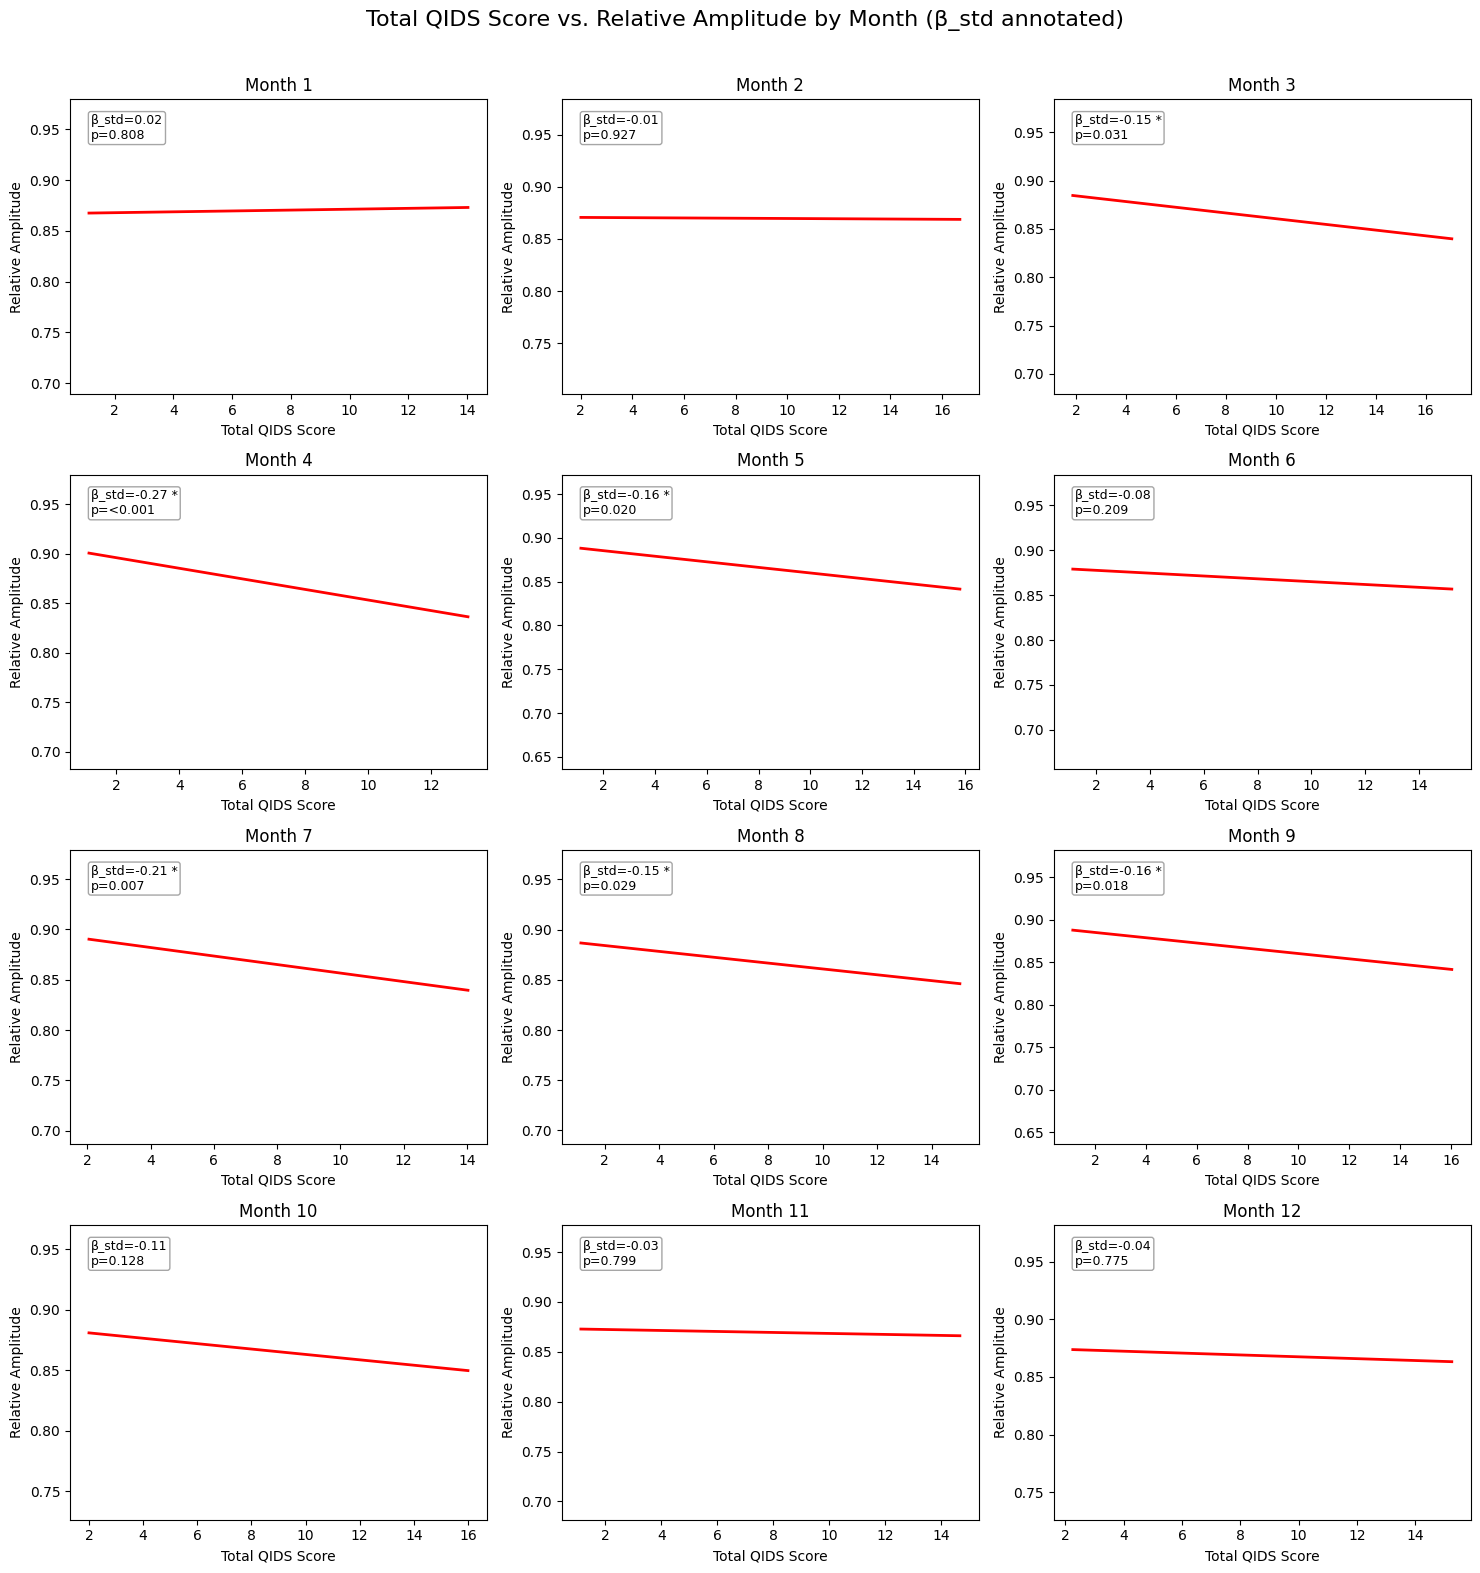

/tmp/ipykernel_2215432/178461746.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh'])
/tmp/ipykernel_2215432/178461746.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh'])
/tmp/ipykernel_2215432/178461746.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh'])
/tmp/ipykernel_2215432/178461746.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh'])
/tmp/ipykernel_2215432/178461746.py:69: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeE

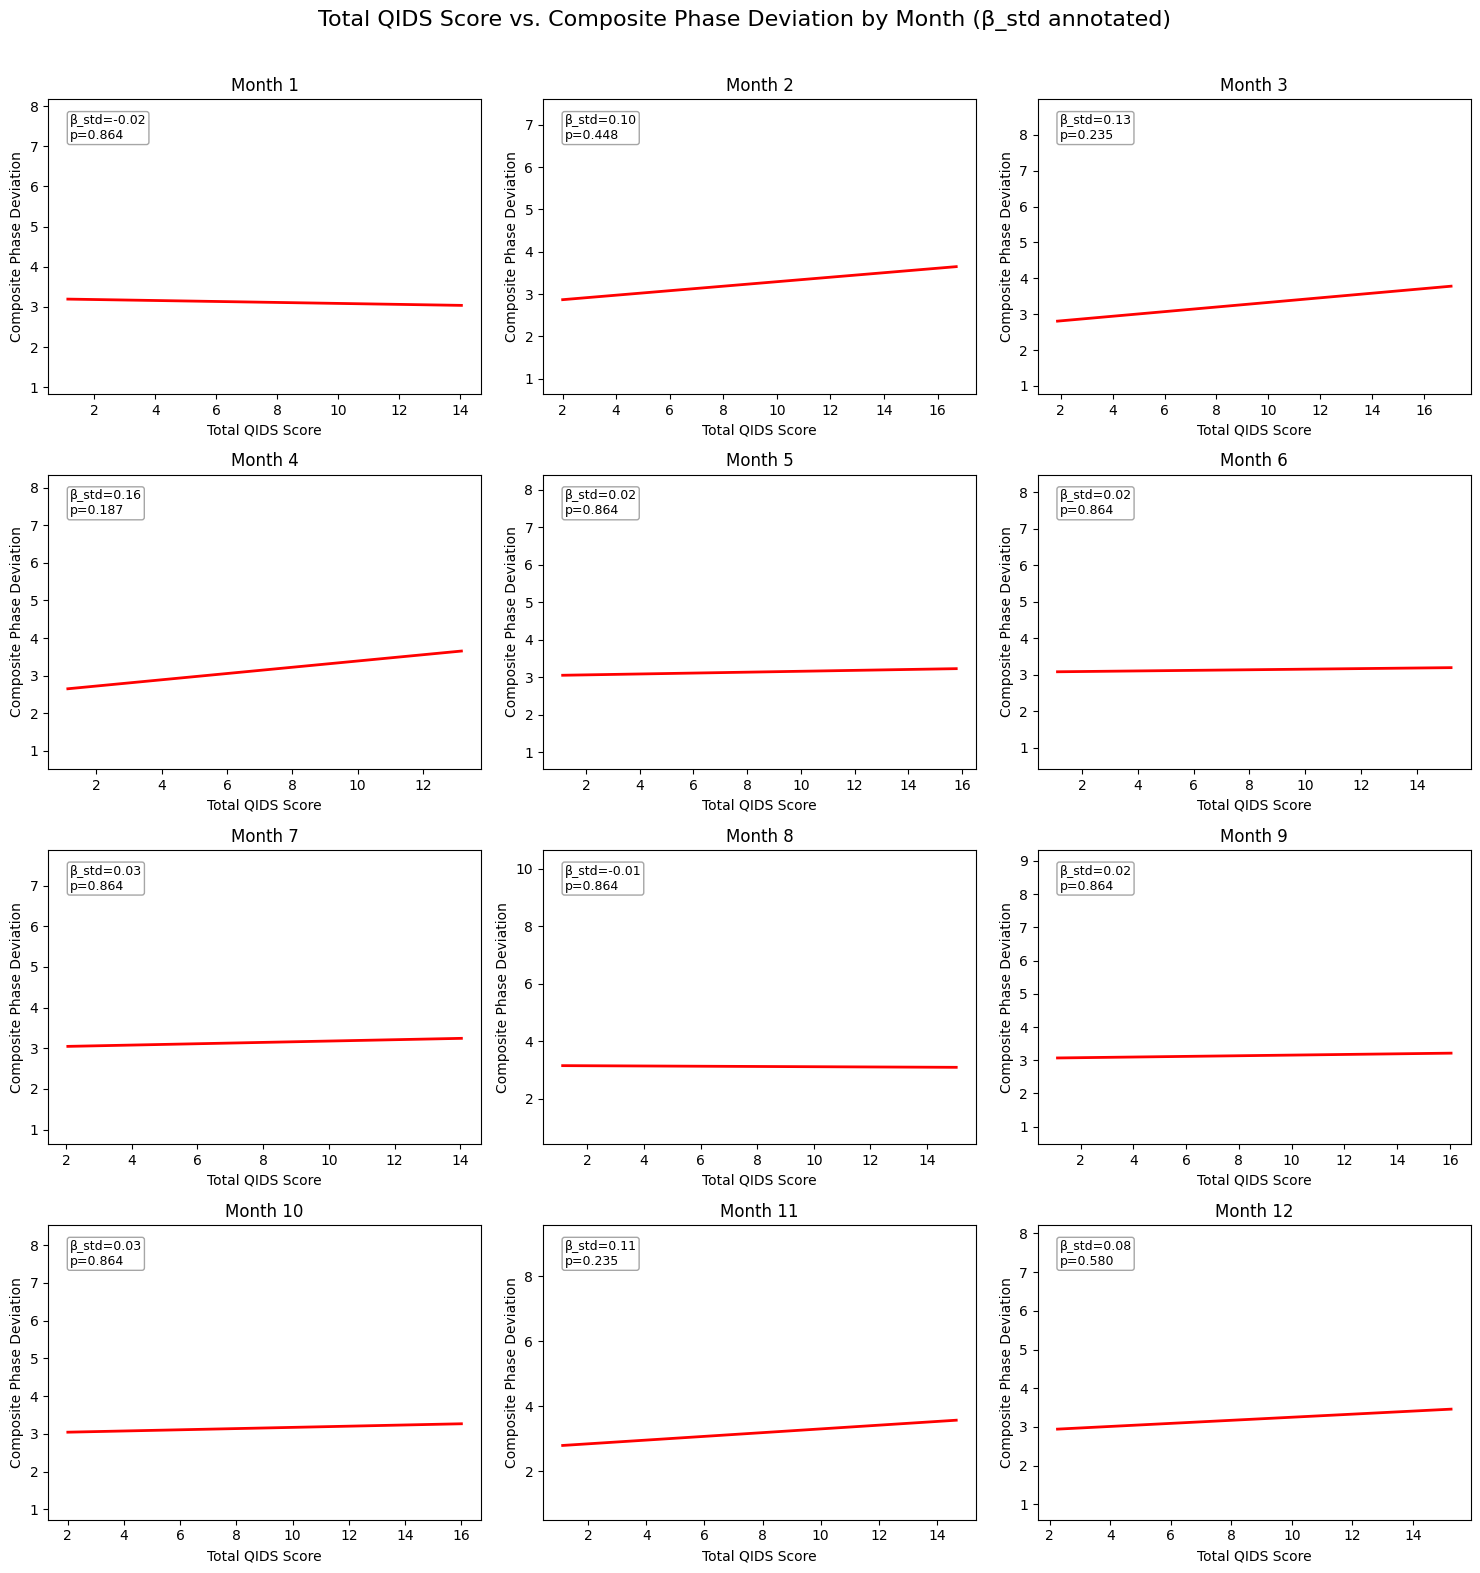

Saved results to temp_files/Overall_Monthly_Analysis_Intercepts_QIDS_11_days.csv


In [45]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------------------------------
# Helper: buffered axis limits for plotting
# -----------------------------------------------------------------------------
def compute_buffered_limits(data, intercept=None, lower_q=0.05, upper_q=0.95, buffer_factor=0.05):
    low, high = np.quantile(data, [lower_q, upper_q])
    if intercept is not None:
        low = min(low, intercept)
        high = max(high, intercept)
    pad = (high - low) * buffer_factor
    return low - pad, high + pad

# -----------------------------------------------------------------------------
# Plotting function: monthly scatter + regression using raw data
# -----------------------------------------------------------------------------
def plot_monthly_grid(model, data_std, data_orig, var, outcome, results_df, readable):
    coefs = model.params
    months = sorted(data_std['month'].unique())

    mean_x = data_orig[var].mean()
    std_x  = data_orig[var].std()
    mean_y = data_orig[outcome].mean()
    std_y  = data_orig[outcome].std()

    fig, axes = plt.subplots(4, 3, figsize=(15,16))
    axes = axes.flatten()

    for ax, m in zip(axes, months):
        df_std = data_std[data_std['month']==m].dropna(subset=[var, outcome])
        if df_std.empty:
            ax.set_visible(False)
            continue

        # raw data points
        x_raw = df_std[var] * std_x + mean_x
        y_raw = df_std[outcome] * std_y + mean_y
        x05, x95 = np.quantile(x_raw, [0.05, 0.95])
        y05, y95 = np.quantile(y_raw, [0.05, 0.95])
        mask = x_raw.between(x05, x95) & y_raw.between(y05, y95)

        # standardized slope
        if m == months[0]:
            std_slope = coefs[var]
        else:
            term = f"{var}:C(month)[T.{m}]"
            std_slope = coefs[var] + coefs.get(term, 0)
        
        # raw slope & intercept for FLIPPED regression
        beta_raw = std_slope * (std_x / std_y)
        intercept = mean_x - beta_raw * mean_y

        # regression line (flipped)
        ys = np.linspace(y05, y95, 100)
        xs = intercept + beta_raw * ys
        ax.plot(ys, xs, color='red', lw=2)

        # p-value
        row = results_df.query(
            "energy_activity_var == @var and qids_var == @outcome and month == @m"
        )
        p_bh = float(row['p_value_bh'])
        star = ' *' if p_bh < 0.05 else ''
        p_str = '<0.001' if p_bh < 0.001 else f"{p_bh:.3f}"

        # title & subtitle
        ax.set_title(f"Month {m}", fontsize=12)
        subtitle = f"β_std={std_slope:.2f}{star}\np={p_str}"
        ax.text(0.05, 0.95, subtitle, transform=ax.transAxes,
                fontsize=9, va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.7))

        # axis limits
        ax.set_xlim(compute_buffered_limits(y_raw))
        ax.set_ylim(compute_buffered_limits(x_raw, intercept))
        ax.set_xlabel(readable[outcome])
        ax.set_ylabel(readable[var])

    for ax in axes[len(months):]:
        ax.set_visible(False)

    fig.suptitle(f"{readable[outcome]} vs. {readable[var]} by Month (β_std annotated)", fontsize=16)
    fig.subplots_adjust(top=0.97)
    plt.tight_layout(rect=[0,0,1,0.97])
    plt.show()

# -----------------------------------------------------------------------------
# Main: prepare data, run LME, collect results & plot
# -----------------------------------------------------------------------------
raw_path = "/home/mayankramchandani/Actigraphy/WELLNESS/temp_files/11_days_actigraphy_part5_qids_MSFCPD.csv"
data_orig = pd.read_csv(raw_path)
data_orig['month'] = pd.to_datetime(data_orig['qids_date']).dt.month

# Load metadata with age, sex, and baseline qids info
meta_path = "/home/mayankramchandani/Actigraphy/WELLNESS/data/output_raw gt3x files/wellness20200527.xlsx"
df_meta = pd.read_excel(meta_path)

# Clean and rename relevant columns for merge
meta_subset = df_meta[['subjID', 'age', 'sex']].copy()
meta_subset.columns = ['qids_id', 'age', 'sex']

# Merge into original data
# First ensure consistent formats for merge key
data_orig['qids_id'] = data_orig['qids_id'].astype(str).str.strip()
meta_subset['qids_id'] = meta_subset['qids_id'].astype(str).str.strip()

# Merge
merged_df = data_orig.merge(meta_subset, on='qids_id', how='left')

energy_vars = ['relative_amplitude','CPD']
qids_vars  = ['qidsrtot']
all_vars = energy_vars + qids_vars

# Drop NA for key vars and standardize
covariates = ['age', 'sex']
all_vars_extended = all_vars + covariates

# standardize
scaler = StandardScaler()
data_std = merged_df.dropna(subset=['qids_id','month']+all_vars_extended).copy()
data_std[all_vars_extended] = scaler.fit_transform(data_std[all_vars_extended])

readable = {
    'relative_amplitude': 'Relative Amplitude',
    'CPD':               'Composite Phase Deviation',
    'qidsrtot':       'Total QIDS Score',
}

results_list = []
results_file = "temp_files/Overall_Monthly_Analysis_Intercepts_QIDS_11_days.csv"

for var in energy_vars:
    for outcome in qids_vars:
        df = data_std.dropna(subset=[var,outcome,'month','qids_id'])
        if len(df) < 2:
            continue
        # fit LME
        model = smf.mixedlm(
        f"{outcome} ~ {var} * C(month) + age + sex ", # + qids_baseline
        re_formula='1',
        groups=df['qids_id'],
        data=df
        ).fit()

        # collect month effects
        coefs = model.params
        cov   = model.cov_params()
        rows = []
        months = sorted(df['month'].unique())
        for m in months:
            if m == months[0]:
                bs = coefs[var]; se = np.sqrt(cov.loc[var,var]); p0 = model.pvalues[var]
            else:
                term = f"{var}:C(month)[T.{m}]"
                bs = coefs[var] + coefs.get(term,0)
                v_main = cov.loc[var,var]
                v_int  = cov.loc[term,term] if term in cov.index else 0
                covar  = cov.loc[var,term] if term in cov.index else 0
                se = np.sqrt(v_main + v_int + 2*covar)
                t = bs/se if se else 0
                p0 = 2*(1-norm.cdf(abs(t)))
            rows.append({'energy_activity_var':var,'qids_var':outcome,'month':m,
                         'beta_std':bs,'se_std':se,'p_value':p0})
        month_df = pd.DataFrame(rows)
        reject,p_adj,_,_ = multipletests(month_df['p_value'], method='fdr_bh')
        month_df['p_value_bh']=p_adj
        results_list.append(month_df)
        plot_monthly_grid(model, data_std, data_orig, var, outcome,
                          pd.concat(results_list,ignore_index=True), readable)

if results_list:
    pd.concat(results_list,ignore_index=True).to_csv(results_file,index=False)
    print(f"Saved results to {results_file}")


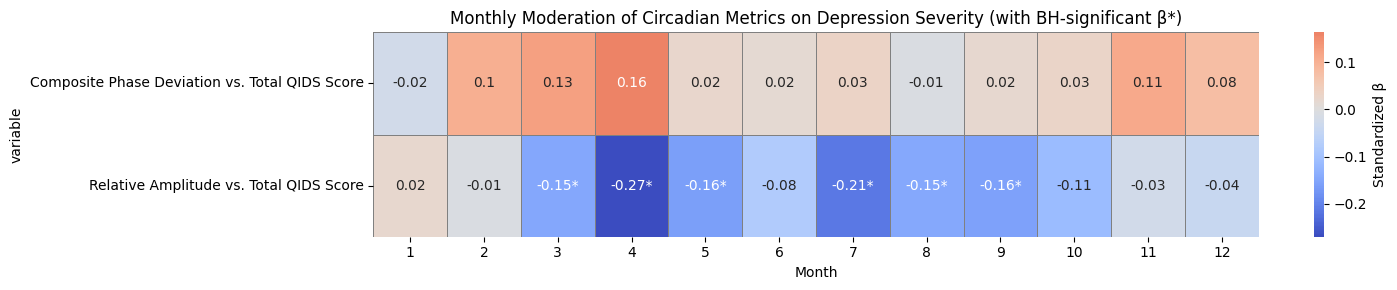

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load results
df = pd.read_csv("temp_files/Overall_Monthly_Analysis_Intercepts_QIDS_11_days.csv")

# Composite variable label
df["variable"] = df["energy_activity_var"].map(readable) + " vs. " + df["qids_var"].map(readable)

# Round beta and annotate significant values
df["beta_label"] = df["beta_std"].round(2).astype(str)
df.loc[df["p_value_bh"] < 0.05, "beta_label"] += "*"

# Pivot table for heatmap
pivot_table = df.pivot(index="variable", columns="month", values="beta_label")
pivot_values = df.pivot(index="variable", columns="month", values="beta_std")

# Plot heatmap
plt.figure(figsize=(15, 3))
ax = sns.heatmap(
    pivot_values,
    annot=pivot_table,
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Standardized β"}
)

# Labels
plt.title("Monthly Moderation of Circadian Metrics on Depression Severity (with BH-significant β*)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()


### Table

In [47]:
import pandas as pd
import numpy as np
import calendar

# 1. Load CSV
results_file = "temp_files/Overall_Monthly_Analysis_Intercepts_QIDS_11_days.csv"
df = pd.read_csv(results_file)

# 2. Convert numeric months to month names (if necessary)
def month_to_name(x):
    try:
        m = int(x)
        return calendar.month_name[m]
    except:
        return str(x)

if df["month"].dtype in [int, np.int64] or df["month"].apply(lambda x: str(x).isdigit()).all():
    df["Month"] = df["month"].apply(month_to_name)
else:
    df["Month"] = df["month"].astype(str)

# 3. Compute 95% CIs around beta_std
z = 1.96
df["ci_lower"] = df["beta_std"] - z * df["se_std"]
df["ci_upper"] = df["beta_std"] + z * df["se_std"]

# 4. Format each cell as "β [lower, upper], p=..."
def format_cell(row):
    beta = row["beta_std"]
    lower = row["ci_lower"]
    upper = row["ci_upper"]
    pval = row["p_value_bh"]
    beta_str = f"{beta:.2f}"
    lower_str = f"{lower:.2f}"
    upper_str = f"{upper:.2f}"
    p_str = "<.001" if pval < 0.001 else f"{pval:.3f}"
    return f"{beta_str} [{lower_str}, {upper_str}], p={p_str}"

df["cell_text"] = df.apply(format_cell, axis=1)

# 5. Create a composite column name and pivot
df["Label"] = df["qids_var"] + " vs. " + df["energy_activity_var"]
table_df = df.pivot(index="Month", columns="Label", values="cell_text")

# 6. Reorder months January→December (keep only those present)
ordered_months = [m for m in calendar.month_name[1:] if m in table_df.index]
table_df = table_df.reindex(ordered_months)

# 7. Reset index so "Month" is a column
apa_df = table_df.reset_index()

# 8. Build an APA‐style ASCII table manually
#    - Compute max width for each column
columns = list(apa_df.columns)
col_widths = []
for col in columns:
    max_content = apa_df[col].astype(str).map(len).max()
    header_len = len(col)
    col_widths.append(max(max_content, header_len))

# 9. Helper to create a horizontal rule
def horizontal_rule(widths, sep="  "):
    total = sum(widths) + len(sep) * (len(widths) - 1)
    return "-" * total

# 10. Print table header (Table number and title)
print("Table 1\n")
print("Regression Coefficients (β) and 95% Confidence Intervals [CI], and p-Values by Month\n")

# 11. Print column names row
header_cells = []
for col, w in zip(columns, col_widths):
    header_cells.append(col.ljust(w))
print("  ".join(header_cells))

# 12. Print a rule under the header
print(horizontal_rule(col_widths))

# 13. Print each data row
for _, row in apa_df.iterrows():
    row_cells = []
    for col, w in zip(columns, col_widths):
        cell = str(row[col])
        row_cells.append(cell.ljust(w))
    print("  ".join(row_cells))

# 14. Print bottom rule
print(horizontal_rule(col_widths))

# 15. Print the note underneath
note = ("Note. Values are standardized regression coefficients (β) with 95% confidence intervals "
        "in brackets; p-values adjusted via Benjamini–Hochberg procedure.")
print(f"\n{note}")


Table 1

Regression Coefficients (β) and 95% Confidence Intervals [CI], and p-Values by Month

Month      qidsrtot vs. CPD              qidsrtot vs. relative_amplitude
------------------------------------------------------------------------
January    -0.02 [-0.15, 0.11], p=0.864  0.02 [-0.11, 0.15], p=0.808    
February   0.10 [-0.04, 0.25], p=0.448   -0.01 [-0.15, 0.13], p=0.927   
March      0.13 [-0.00, 0.26], p=0.235   -0.15 [-0.27, -0.03], p=0.031  
April      0.16 [0.03, 0.30], p=0.187    -0.27 [-0.39, -0.15], p=<.001  
May        0.02 [-0.10, 0.15], p=0.864   -0.16 [-0.28, -0.04], p=0.020  
June       0.02 [-0.10, 0.13], p=0.864   -0.08 [-0.19, 0.03], p=0.209   
July       0.03 [-0.10, 0.17], p=0.864   -0.21 [-0.34, -0.08], p=0.007  
August     -0.01 [-0.10, 0.09], p=0.864  -0.15 [-0.26, -0.03], p=0.029  
September  0.02 [-0.09, 0.13], p=0.864   -0.16 [-0.26, -0.05], p=0.018  
October    0.03 [-0.09, 0.15], p=0.864   -0.11 [-0.24, 0.01], p=0.128   
November   0.11 [0.00, 0.22],

## Seasonal Analysis

/tmp/ipykernel_2215432/3282826504.py:65: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh'])
/tmp/ipykernel_2215432/3282826504.py:65: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh'])
/tmp/ipykernel_2215432/3282826504.py:65: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh'])
/tmp/ipykernel_2215432/3282826504.py:65: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh'])


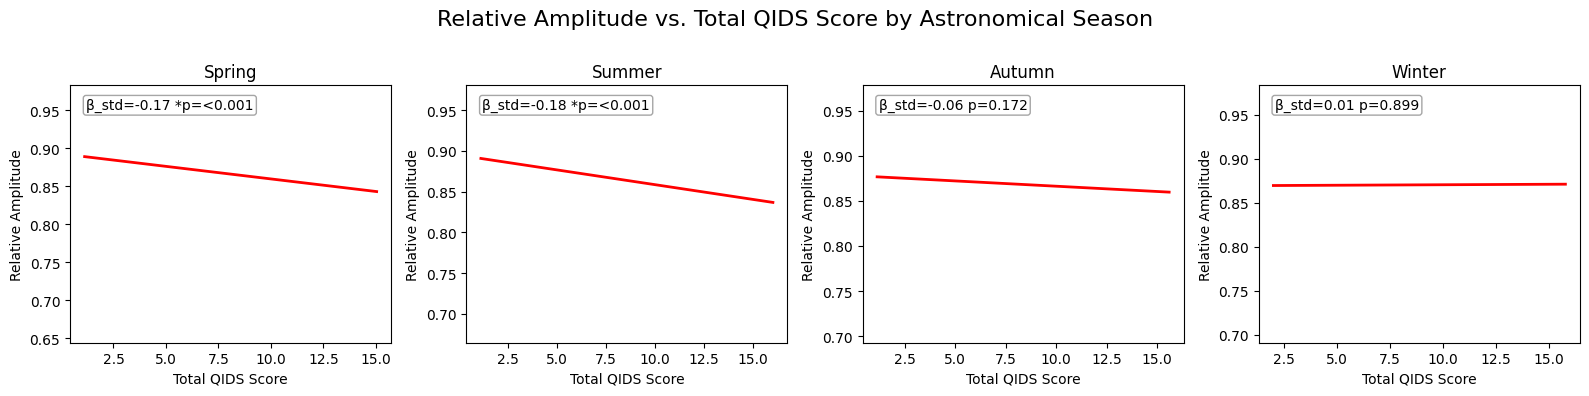

/tmp/ipykernel_2215432/3282826504.py:65: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh'])
/tmp/ipykernel_2215432/3282826504.py:65: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh'])
/tmp/ipykernel_2215432/3282826504.py:65: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh'])
/tmp/ipykernel_2215432/3282826504.py:65: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh'])


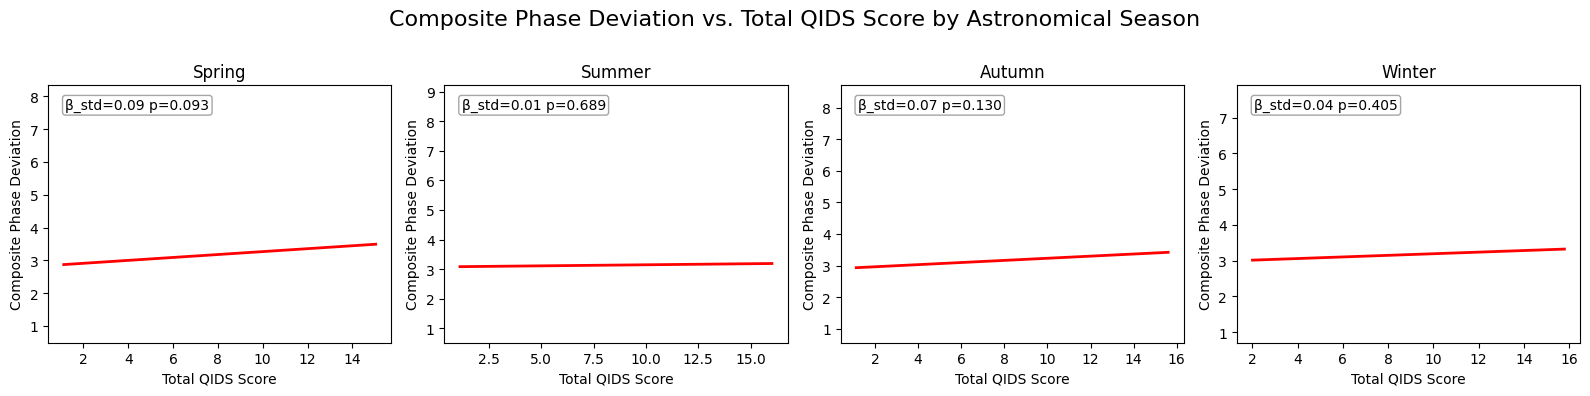

Saved all seasonal results to temp_files/Seasonal_Marginal_Effects_QIDS_11_days.csv


In [48]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------------------------------
# Helper: buffered axis limits for plotting
# -----------------------------------------------------------------------------
def compute_buffered_limits(data, intercept=None, lower_q=0.05, upper_q=0.95, buffer_factor=0.05):
    low, high = np.quantile(data, [lower_q, upper_q])
    if intercept is not None:
        low = min(low, intercept)
        high = max(high, intercept)
    pad = (high - low) * buffer_factor
    return low - pad, high + pad

# -----------------------------------------------------------------------------
# Plotting function: seasonal scatter + regression using raw data
# -----------------------------------------------------------------------------
# Replace the content inside plot_season_grid with the flipped version
def plot_season_grid(model, data_std, data_orig, var, outcome, results_df, readable, seasons_order):
    coefs = model.params
    mean_x = data_orig[var].mean()
    std_x  = data_orig[var].std()
    mean_y = data_orig[outcome].mean()
    std_y  = data_orig[outcome].std()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes = axes.flatten()

    for ax, season in zip(axes, seasons_order):
        df_std = data_std[data_std['season'] == season].dropna(subset=[var, outcome])
        if df_std.empty:
            ax.set_visible(False)
            continue

        x_raw = df_std[var] * std_x + mean_x
        y_raw = df_std[outcome] * std_y + mean_y

        x05, x95 = np.quantile(x_raw, [0.05, 0.95])
        y05, y95 = np.quantile(y_raw, [0.05, 0.95])
        mask = x_raw.between(x05, x95) & y_raw.between(y05, y95)

        if season == seasons_order[0]:
            slope_std = coefs[var]
        else:
            term = f"{var}:C(season)[T.{season}]"
            slope_std = coefs[var] + coefs.get(term, 0)

        # Flip slope and intercept
        beta = slope_std * (std_x / std_y)
        intercept = mean_x - beta * mean_y

        ys = np.linspace(y05, y95, 100)
        xs = intercept + beta * ys
        ax.plot(ys, xs, color='red', lw=2)

        row = results_df.query(
            "energy_activity_var == @var and qids_var == @outcome and season == @season"
        )
        p_bh = float(row['p_value_bh'])
        star = ' *' if p_bh < 0.05 else ' '
        p_str = '<0.001' if p_bh < 0.001 else f"{p_bh:.3f}"

        ax.set_title(f"{season}")
        subtitle = f"β_std={slope_std:.2f}{star}p={p_str}"
        ax.text(0.05, 0.95, subtitle, transform=ax.transAxes,
                fontsize=10, va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.7))

        ax.set_xlim(compute_buffered_limits(y_raw))
        ax.set_ylim(compute_buffered_limits(x_raw, intercept))
        ax.set_xlabel(readable[outcome])
        ax.set_ylabel(readable[var])

    plt.suptitle(f"{readable[var]} vs. {readable[outcome]} by Astronomical Season", fontsize=16)
    fig.subplots_adjust(top=0.92)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# -----------------------------------------------------------------------------
# Main: seasonal marginal effects analysis and plotting
# -----------------------------------------------------------------------------
# Load and prepare raw data
raw_path = "/home/mayankramchandani/Actigraphy/WELLNESS/temp_files/11_days_actigraphy_part5_qids_MSFCPD.csv"
data_orig = pd.read_csv(raw_path)
data_orig['month'] = pd.to_datetime(data_orig['qids_date']).dt.month
# Map months to seasons
def get_season(m):
    if m in [4,5,6]: return 'Spring'
    if m in [7,8,9]: return 'Summer'
    if m in [10,11,12]: return 'Autumn'
    if m in [1,2,3]: return 'Winter'
    return np.nan

data_orig['qids_date'] = pd.to_datetime(data_orig['qids_date'])

# Define date-only season boundaries (midnight of each date)
season_starts = {
    2016: {
        'Spring': pd.Timestamp("2016-03-20"),
        'Summer': pd.Timestamp("2016-06-20"),
        'Autumn': pd.Timestamp("2016-09-22"),
        'Winter': pd.Timestamp("2016-12-21"),
    },
    2017: {
        'Spring': pd.Timestamp("2017-03-20"),
        'Summer': pd.Timestamp("2017-06-21"),
        'Autumn': pd.Timestamp("2017-09-22"),
        'Winter': pd.Timestamp("2017-12-21"),
    },
    2018: {
        'Spring': pd.Timestamp("2018-03-20"),
        'Summer': pd.Timestamp("2018-06-21"),
        'Autumn': pd.Timestamp("2018-09-23"),
        'Winter': pd.Timestamp("2018-12-21"),
    },
    2019: {
        'Spring': pd.Timestamp("2019-03-20"),
        'Summer': pd.Timestamp("2019-06-21"),
        'Autumn': pd.Timestamp("2019-09-23"),
        'Winter': pd.Timestamp("2019-12-22"),
    },
}

# Function to assign season using date only
def assign_season_by_date(date):
    year = date.year
    if year not in season_starts:
        return np.nan

    spring = season_starts[year]['Spring']
    summer = season_starts[year]['Summer']
    autumn = season_starts[year]['Autumn']
    winter = season_starts[year]['Winter']

    if date < spring:
        return 'Winter'
    elif date < summer:
        return 'Spring'
    elif date < autumn:
        return 'Summer'
    elif date < winter:
        return 'Autumn'
    else:
        return 'Winter'

seasons_order = ['Spring','Summer','Autumn','Winter']
data_orig['season'] = pd.to_datetime(data_orig['qids_date']).apply(assign_season_by_date)
data_std['season'] = pd.to_datetime(data_orig['qids_date']).apply(assign_season_by_date)
data_std['season'] = pd.Categorical(data_std['season'], categories=seasons_order)
data_orig['season'] = pd.Categorical(data_orig['season'], categories=seasons_order)

# Load metadata with age, sex, and baseline qids info
meta_path = "/home/mayankramchandani/Actigraphy/WELLNESS/data/output_raw gt3x files/wellness20200527.xlsx"
df_meta = pd.read_excel(meta_path)

# Clean and rename relevant columns for merge
meta_subset = df_meta[['subjID', 'age', 'sex']].copy()
meta_subset.columns = ['qids_id', 'age', 'sex']

# Merge into original data
# First ensure consistent formats for merge key
data_orig['qids_id'] = data_orig['qids_id'].astype(str).str.strip()
meta_subset['qids_id'] = meta_subset['qids_id'].astype(str).str.strip()

# Merge
merged_df = data_orig.merge(meta_subset, on='qids_id', how='left')

energy_vars = ['relative_amplitude','CPD']

qids_vars  = ['qidsrtot']
all_vars = energy_vars + qids_vars

# Drop NA for key vars and standardize
covariates = ['age', 'sex']
all_vars_extended = all_vars + covariates

# standardize
scaler = StandardScaler()
data_std = merged_df.dropna(subset=['qids_id','season']+all_vars_extended).copy()
data_std[all_vars_extended] = scaler.fit_transform(data_std[all_vars_extended])

# Label mapping
readable = {
    'relative_amplitude':'Relative Amplitude',
    'CPD':'Composite Phase Deviation',
    'qidsrtot':'Total QIDS Score',
}

results_list = []
results_file = "temp_files/Seasonal_Analysis_Intercepts_QIDS_11_days.csv"

# Loop through energy & qids variables
for var in energy_vars:
    for outcome in qids_vars:
        df = data_std.dropna(subset=[var,outcome,'season','qids_id'])
        if len(df) < 2:
            continue
        # Fit LME with season interaction
        model = smf.mixedlm(
        f"{outcome} ~ {var} * C(season) + age + C(sex)", # + qids_baseline
        re_formula='1',
        groups=df['qids_id'],
        data=df
        ).fit()
        # Extract season-specific marginal effects
        coefs = model.params
        cov   = model.cov_params()
        rows = []
        # baseline = first in seasons_order
        for s in seasons_order:
            if s not in df['season'].unique():
                continue
            if s == seasons_order[0]:
                beta_s = coefs[var]
                se_s   = np.sqrt(cov.loc[var,var])
                p0     = model.pvalues[var]
            else:
                term = f"{var}:C(season)[T.{s}]"
                beta_s = coefs[var] + coefs.get(term,0)
                v_main = cov.loc[var,var]
                v_int  = cov.loc[term,term] if term in cov.index else 0
                covar  = cov.loc[var,term]   if term in cov.index else 0
                se_s   = np.sqrt(v_main + v_int + 2*covar)
                t      = beta_s/se_s if se_s else 0
                p0     = 2*(1-norm.cdf(abs(t)))
            ci_l = beta_s - 1.96*se_s
            ci_u = beta_s + 1.96*se_s
            rows.append({'season':s,'energy_activity_var':var,
                         'qids_var':outcome,'beta_std':beta_s,
                         'se_std':se_s,'ci_lower':ci_l,
                         'ci_upper':ci_u,'p_value':p0})
        df_season = pd.DataFrame(rows)
        rej,p_adj,_,_ = multipletests(df_season['p_value'],method='fdr_bh')
        df_season['p_value_bh']=p_adj; df_season['significant']=rej
        results_list.append(df_season)
        # Plot unstandardized scatter/regression per season
        plot_season_grid(model, data_std, data_orig, var, outcome, pd.concat(results_list,ignore_index=True), readable, seasons_order)

all_seasonal_results = pd.concat(results_list, ignore_index=True)

# Save to CSV (so can skip re-running the LME next time)
all_seasonal_results.to_csv(
    "temp_files/Seasonal_Marginal_Effects_QIDS_11_days.csv",
    index=False
)
print("Saved all seasonal results to temp_files/Seasonal_Marginal_Effects_QIDS_11_days.csv")


### Heatmap

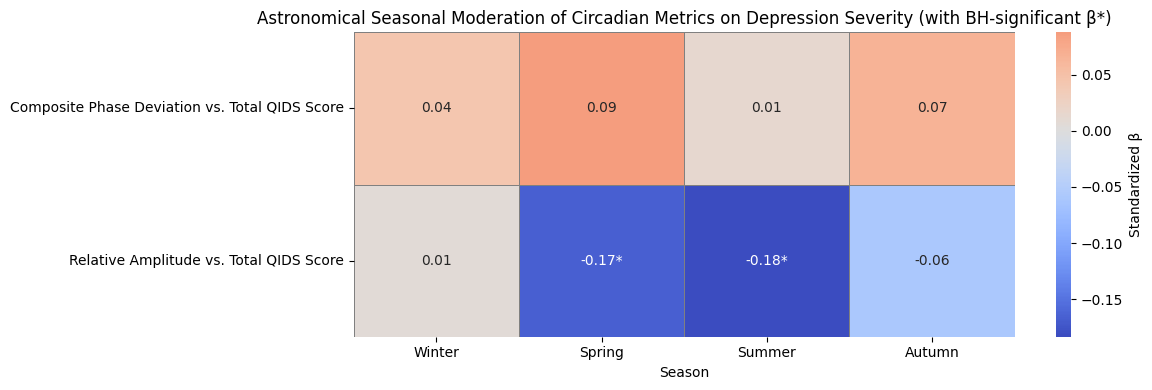

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Read the precomputed results
final_results = pd.read_csv("temp_files/Seasonal_Marginal_Effects_QIDS_11_days.csv")

# 2) If want “readable” names (and the asterisk on significant betas):
readable = {
    'relative_amplitude':'Relative Amplitude',
    'CPD':'Composite Phase Deviation',
    'qidsrtot':'Total QIDS Score',
}

# Add a column “variable” that merges the two names with “ vs. ”
final_results["variable"] = (
    final_results["energy_activity_var"].map(readable) 
    + " vs. " 
    + final_results["qids_var"].map(readable)
)

# Build a “beta_label” string that rounds to 2 decimals, plus “*” if BH < 0.05:
final_results["beta_label"] = final_results["beta_std"].round(2).astype(str)
final_results.loc[final_results["p_value_bh"] < 0.05, "beta_label"] += "*"

# 3) Pivot into a table whose rows = “variable” and columns = seasons
heatmap_vals = final_results.pivot(
    index="variable", 
    columns="season", 
    values="beta_std"
)
heatmap_labels = final_results.pivot(
    index="variable", 
    columns="season", 
    values="beta_label"
)

# Force the column order to be exactly [Spring, Summer, Autumn, Winter]:
seasons_order = ['Winter','Spring','Summer','Autumn']
heatmap_vals   = heatmap_vals.reindex(columns=seasons_order)
heatmap_labels = heatmap_labels.reindex(columns=seasons_order)

# 4) Draw the heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(
    heatmap_vals,
    annot=heatmap_labels,
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Standardized β'}
)
plt.title("Astronomical Seasonal Moderation of Circadian Metrics on Depression Severity (with BH-significant β*)")
plt.xlabel("Season")
plt.ylabel("")   # Leave the y-axis label blank
plt.tight_layout()
plt.show()


### Table

In [50]:
import pandas as pd
import numpy as np
import calendar

# 1. Load CSV
results_file = "temp_files/Seasonal_Marginal_Effects_QIDS_11_days.csv"
df = pd.read_csv(results_file)

# 3. Compute 95% CIs around beta_std
z = 1.96
df["ci_lower"] = df["beta_std"] - z * df["se_std"]
df["ci_upper"] = df["beta_std"] + z * df["se_std"]

# 4. Format each cell as "β [lower, upper], p=..."
def format_cell(row):
    beta = row["beta_std"]
    lower = row["ci_lower"]
    upper = row["ci_upper"]
    pval = row["p_value_bh"]
    beta_str = f"{beta:.2f}"
    lower_str = f"{lower:.2f}"
    upper_str = f"{upper:.2f}"
    p_str = "<.001" if pval < 0.001 else f"{pval:.3f}"
    return f"{beta_str} [{lower_str}, {upper_str}], p={p_str}"

df["cell_text"] = df.apply(format_cell, axis=1)

# 5. Create a composite column name and pivot
df["Label"] = df["qids_var"] + " vs. " + df["energy_activity_var"]
table_df = df.pivot(index="season", columns="Label", values="cell_text")

# 7. Reset index so "Month" is a column
apa_df = table_df.reset_index()

# 8. Build an APA‐style ASCII table manually
#    - Compute max width for each column
columns = list(apa_df.columns)
col_widths = []
for col in columns:
    max_content = apa_df[col].astype(str).map(len).max()
    header_len = len(col)
    col_widths.append(max(max_content, header_len))

# 9. Helper to create a horizontal rule
def horizontal_rule(widths, sep="  "):
    total = sum(widths) + len(sep) * (len(widths) - 1)
    return "-" * total

# 10. Print table header (Table number and title)
print("Table 1\n")
print("Regression Coefficients (β) and 95% Confidence Intervals [CI], and p-Values by Season\n")

# 11. Print column names row
header_cells = []
for col, w in zip(columns, col_widths):
    header_cells.append(col.ljust(w))
print("  ".join(header_cells))

# 12. Print a rule under the header
print(horizontal_rule(col_widths))

# 13. Print each data row
for _, row in apa_df.iterrows():
    row_cells = []
    for col, w in zip(columns, col_widths):
        cell = str(row[col])
        row_cells.append(cell.ljust(w))
    print("  ".join(row_cells))

# 14. Print bottom rule
print(horizontal_rule(col_widths))

# 15. Print the note underneath
note = ("Note. Values are standardized regression coefficients (β) with 95% confidence intervals "
        "in brackets; p-values adjusted via Benjamini–Hochberg procedure.")
print(f"\n{note}")

Table 1

Regression Coefficients (β) and 95% Confidence Intervals [CI], and p-Values by Season

season  qidsrtot vs. CPD             qidsrtot vs. relative_amplitude
--------------------------------------------------------------------
Autumn  0.07 [-0.00, 0.14], p=0.130  -0.06 [-0.14, 0.02], p=0.172   
Spring  0.09 [0.01, 0.16], p=0.093   -0.17 [-0.24, -0.10], p=<.001  
Summer  0.01 [-0.05, 0.08], p=0.689  -0.18 [-0.26, -0.11], p=<.001  
Winter  0.04 [-0.04, 0.13], p=0.405  0.01 [-0.08, 0.09], p=0.899    
--------------------------------------------------------------------

Note. Values are standardized regression coefficients (β) with 95% confidence intervals in brackets; p-values adjusted via Benjamini–Hochberg procedure.


In [51]:
raw_path = "temp_files/11_days_actigraphy_part5_qids_MSFCPD.csv"
summary_df = pd.read_csv(raw_path)
summary_df.columns

Index(['qids_id', 'qids_date', 'relative_amplitude', 'MEAN_TEMPERATURE',
       'Hours of illumination (day)', 'qids_sr_1', 'qids_sr_2', 'qids_sr_3',
       'qids_sr_4', 'qids_sr_5', 'qids_sr_6', 'qids_sr_7', 'qids_sr_8',
       'qids_sr_9', 'qids_sr_10', 'qids_sr_11', 'qids_sr_12', 'qids_sr_13',
       'qids_sr_14', 'qids_sr_15', 'qids_sr_16', 'qidsrtotscore', 'qidsintact',
       'qidsnoniatotscore', 'qidsrtot', 'CPD'],
      dtype='object')

## Light, Temperature Interactions

#TODO : Fix light temperature interaction models, and copy paste tabular data from months and seasons to the paper

/home/mayankramchandani/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


                                      Mixed Linear Model Regression Results
Model:                               MixedLM                    Dependent Variable:                    qidsrtot  
No. Observations:                    1576                       Method:                                REML      
No. Groups:                          92                         Scale:                                 0.4375    
Min. group size:                     1                          Log-Likelihood:                        -1726.6362
Max. group size:                     46                         Converged:                             Yes       
Mean group size:                     17.1                                                                        
-----------------------------------------------------------------------------------------------------------------
                                                                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------

/tmp/ipykernel_4156635/1734768365.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh']) if not row.empty else 1.0
/tmp/ipykernel_4156635/1734768365.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh']) if not row.empty else 1.0
/tmp/ipykernel_4156635/1734768365.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh']) if not row.empty else 1.0
/tmp/ipykernel_4156635/1734768365.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh']) if not row.empty else 1.0


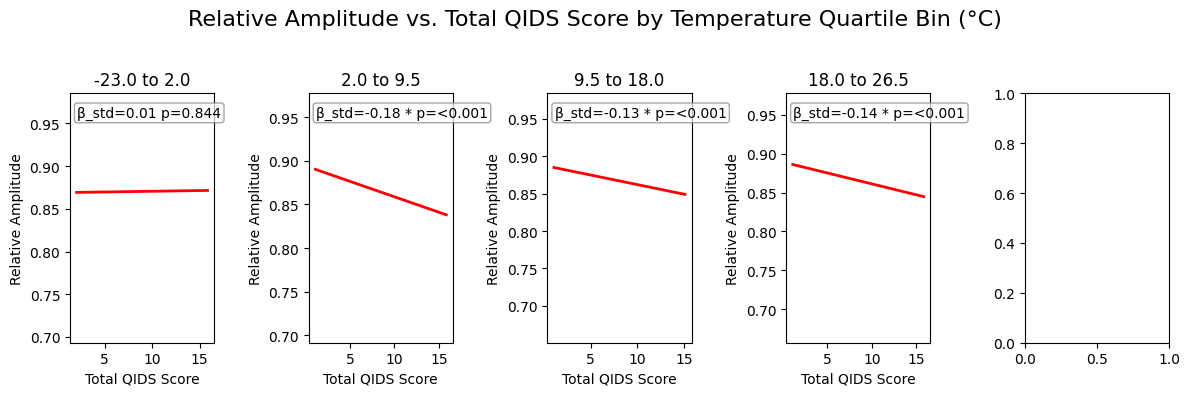

                              Mixed Linear Model Regression Results
Model:                          MixedLM               Dependent Variable:               qidsrtot  
No. Observations:               1576                  Method:                           REML      
No. Groups:                     92                    Scale:                            0.4457    
Min. group size:                1                     Log-Likelihood:                   -1741.1792
Max. group size:                46                    Converged:                        Yes       
Mean group size:                17.1                                                              
--------------------------------------------------------------------------------------------------
                                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------------
Intercept                                

/tmp/ipykernel_4156635/1734768365.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh']) if not row.empty else 1.0
/tmp/ipykernel_4156635/1734768365.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh']) if not row.empty else 1.0
/tmp/ipykernel_4156635/1734768365.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh']) if not row.empty else 1.0
/tmp/ipykernel_4156635/1734768365.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh']) if not row.empty else 1.0


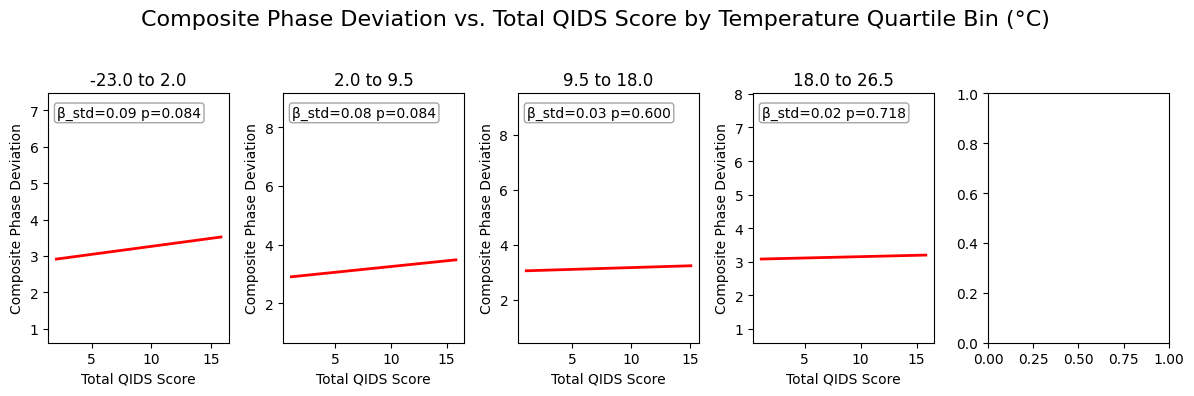

Saved to temp_files/Marginal_Effects_temp_bin_QIDS_11_days.csv


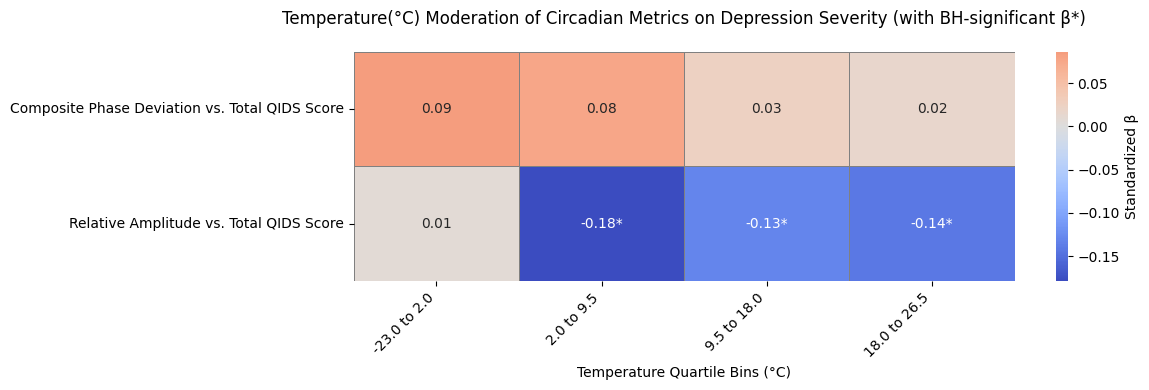

                                      Mixed Linear Model Regression Results
Model:                                MixedLM                    Dependent Variable:                    qidsrtot  
No. Observations:                     1576                       Method:                                REML      
No. Groups:                           92                         Scale:                                 0.4372    
Min. group size:                      1                          Log-Likelihood:                        -1726.5453
Max. group size:                      46                         Converged:                             Yes       
Mean group size:                      17.1                                                                        
------------------------------------------------------------------------------------------------------------------
                                                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----

/tmp/ipykernel_4156635/1734768365.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh']) if not row.empty else 1.0
/tmp/ipykernel_4156635/1734768365.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh']) if not row.empty else 1.0
/tmp/ipykernel_4156635/1734768365.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh']) if not row.empty else 1.0
/tmp/ipykernel_4156635/1734768365.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh']) if not row.empty else 1.0


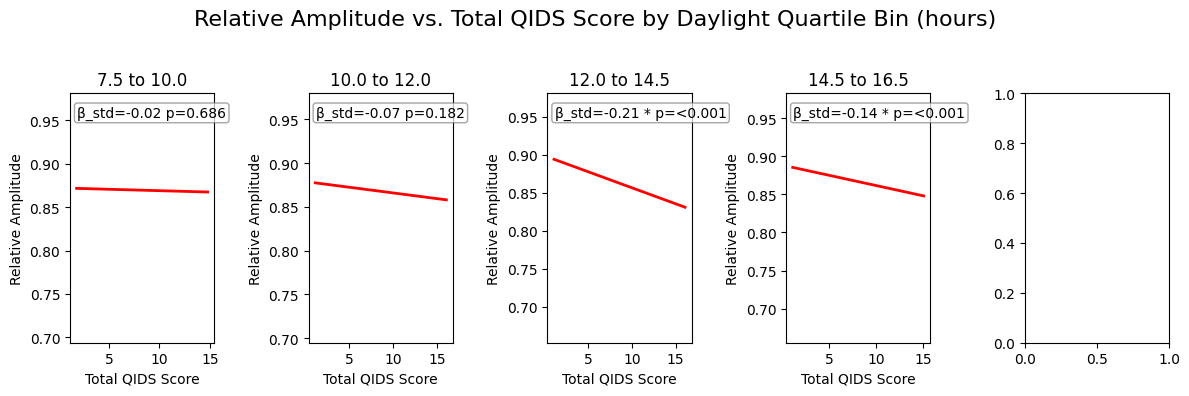

                               Mixed Linear Model Regression Results
Model:                           MixedLM               Dependent Variable:               qidsrtot  
No. Observations:                1576                  Method:                           REML      
No. Groups:                      92                    Scale:                            0.4465    
Min. group size:                 1                     Log-Likelihood:                   -1742.7582
Max. group size:                 46                    Converged:                        Yes       
Mean group size:                 17.1                                                              
---------------------------------------------------------------------------------------------------
                                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------------
Intercept                      

/tmp/ipykernel_4156635/1734768365.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh']) if not row.empty else 1.0
/tmp/ipykernel_4156635/1734768365.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh']) if not row.empty else 1.0
/tmp/ipykernel_4156635/1734768365.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh']) if not row.empty else 1.0
/tmp/ipykernel_4156635/1734768365.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_bh = float(row['p_value_bh']) if not row.empty else 1.0


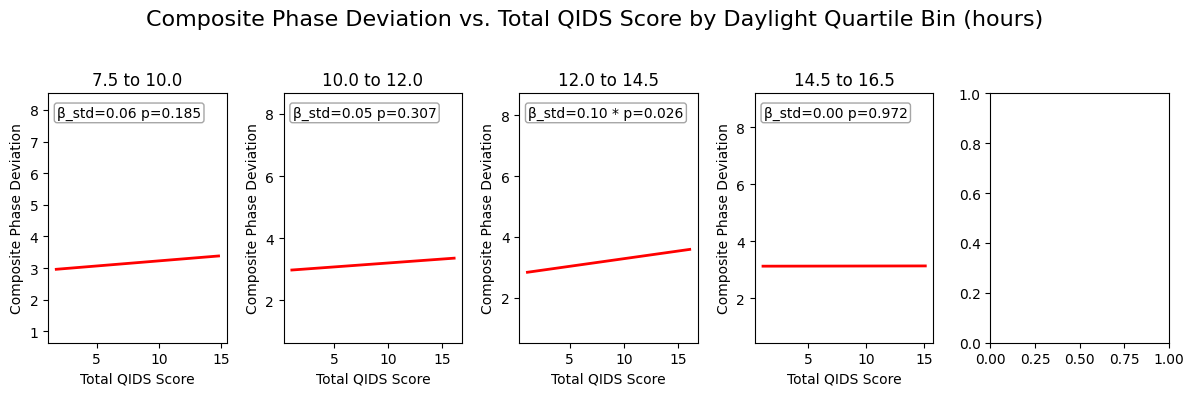

Saved to temp_files/Marginal_Effects_light_bin_QIDS_11_days.csv


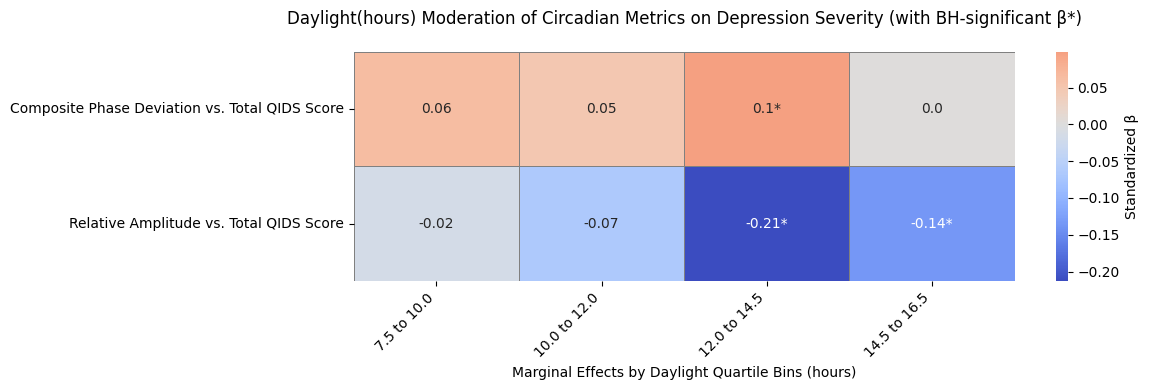

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------------------------------
# Helper Functions
# -----------------------------------------------------------------------------
def compute_buffered_limits(data, intercept=None, lower_q=0.05, upper_q=0.95, buffer_factor=0.05):
    low, high = np.quantile(data, [lower_q, upper_q])
    if intercept is not None:
        low = min(low, intercept)
        high = max(high, intercept)
    pad = (high - low) * buffer_factor
    return low - pad, high + pad

def plot_bin_grid(model, data_std, data_orig, var, outcome, results_df, readable, bin_column, bin_labels):
    coefs = model.params
    mean_x = data_orig[var].mean()
    std_x  = data_orig[var].std()
    mean_y = data_orig[outcome].mean()
    std_y  = data_orig[outcome].std()

    n_bins = len(bin_labels)
    fig, axes = plt.subplots(1, 5, figsize=(12, 4))
    axes = axes.flatten()

    for i, label in enumerate(bin_labels):
        ax = axes[i]
        df_std = data_std[data_std[bin_column] == label].dropna(subset=[var, outcome])
        if df_std.empty:
            ax.set_visible(False)
            continue

        x_raw = df_std[var] * std_x + mean_x
        y_raw = df_std[outcome] * std_y + mean_y

        x05, x95 = np.quantile(x_raw, [0.05, 0.95])
        y05, y95 = np.quantile(y_raw, [0.05, 0.95])
        mask = x_raw.between(x05, x95) & y_raw.between(y05, y95)

        if i == 0:
            slope_std = coefs[var]
        else:
            term = f"{var}:C({bin_column})[T.{repr(label)}]"
            slope_std = coefs[var] + coefs.get(term, 0)

        beta = slope_std * (std_x / std_y)
        intercept = mean_x - beta * mean_y

        ys = np.linspace(y05, y95, 100)
        xs = intercept + beta * ys
        ax.plot(ys, xs, color='red', lw=2)

        row = results_df.query(
            f"energy_activity_var == @var and qids_var == @outcome and {bin_column} == @label"
        )
        p_bh = float(row['p_value_bh']) if not row.empty else 1.0
        star = ' *' if p_bh < 0.05 else ''
        p_str = '<0.001' if p_bh < 0.001 else f"{p_bh:.3f}"

        subtitle = f"\u03b2_std={slope_std:.2f}{star} p={p_str}"
        ax.text(0.05, 0.95, subtitle, transform=ax.transAxes,
                fontsize=10, va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.7))

        ax.set_xlim(compute_buffered_limits(y_raw))
        ax.set_ylim(compute_buffered_limits(x_raw, intercept))
        ax.set_xlabel(readable[outcome])
        ax.set_ylabel(readable[var])
        left, right = label.left, label.right
        if bin_column == 'temp_bin':
            new_label = f"{left:.1f} to {right:.1f}"
        else:  # light_bin
            new_label = f"{left:.1f} to {right:.1f}"

        ax.set_title(new_label)

    if bin_column == 'temp_bin':
        supertitle = f"{readable[var]} vs. {readable[outcome]} by Temperature Quartile Bin (°C)"
    else:
        supertitle = f"{readable[var]} vs. {readable[outcome]} by Daylight Quartile Bin (hours)"
    plt.suptitle(supertitle, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# -----------------------------------------------------------------------------
# Main Analysis
# -----------------------------------------------------------------------------
raw_path = "temp_files/11_days_actigraphy_part5_qids_MSFCPD.csv"
summary_df = pd.read_csv(raw_path)
summary_df['qids_date'] = pd.to_datetime(summary_df['qids_date'])

energy_activity_variables = ['relative_amplitude', 'CPD']
qids_vars  = ['qidsrtot']
readable = {
    'relative_amplitude': 'Relative Amplitude',
    'CPD': 'Composite Phase Deviation',
    'qidsrtot': 'Total QIDS Score',
}

# Load metadata with age, sex, and baseline qids info
meta_path = "/home/mayankramchandani/Actigraphy/WELLNESS/data/output_raw gt3x files/wellness20200527.xlsx"
df_meta = pd.read_excel(meta_path)

# Clean and rename relevant columns for merge
meta_subset = df_meta[['subjID', 'age', 'sex']].copy()
meta_subset.columns = ['qids_id', 'age', 'sex']

# Merge into original data
# First ensure consistent formats for merge key
summary_df['qids_id'] = summary_df['qids_id'].astype(str).str.strip()
meta_subset['qids_id'] = meta_subset['qids_id'].astype(str).str.strip()

# Merge
data_orig = summary_df.merge(meta_subset, on='qids_id', how='left')

energy_vars = ['relative_amplitude','CPD']
qids_vars  = ['qidsrtot']
all_vars = energy_vars + qids_vars

# Drop NA for key vars and standardize
covariates = ['age', 'sex']
all_vars_extended = all_vars + covariates

# Add bins to both
temp_bins = [-23, 2, 9.5, 18, 26.5]
data_orig['temp_bin'] = pd.cut(data_orig['MEAN_TEMPERATURE'], bins=temp_bins)

# Daylight bins: 8 to 10, 10 to 12, 12 to 14.5, 14.5 to 16.5
light_bins = [7.5, 10, 12, 14.5 ,16.5]
data_orig['light_bin'] = pd.cut(data_orig['Hours of illumination (day)'], bins=light_bins)
# grab the automatically generated IntervalIndex…
temp_cats = data_orig['temp_bin'].cat.categories
light_cats = data_orig['light_bin'].cat.categories

# standardize
scaler = StandardScaler()
data_std = data_orig.dropna(subset=['qids_id','temp_bin', 'light_bin']+all_vars_extended).copy()
data_std[all_vars_extended] = scaler.fit_transform(data_std[all_vars_extended])

# sort them by the .left attribute
temp_cats_sorted  = sorted(temp_cats,  key=lambda iv: iv.left)
light_cats_sorted = sorted(light_cats, key=lambda iv: iv.left)

# now reorder Categorical with these sorted categories
data_orig['temp_bin']  = data_orig['temp_bin'].cat.reorder_categories(temp_cats_sorted,  ordered=True)
data_std['light_bin'] = data_std['light_bin'].cat.reorder_categories(light_cats_sorted, ordered=True)

results_all = []

for bin_col in ['temp_bin', 'light_bin']:
    bin_results = []
    bin_labels = data_std[bin_col].cat.categories

    for var in energy_activity_variables:
        for outcome in qids_vars:
            df = data_std.dropna(subset=[var, outcome, bin_col, 'qids_id'])
            if len(df) < 2:
                continue
            model = smf.mixedlm(
            f"{outcome} ~ {var} * C({bin_col}) + age + sex", #  + qids_baseline
            re_formula='1',
            groups=df['qids_id'],
            data=df
            ).fit()
            
            coefs = model.params
            cov = model.cov_params()
            print(model.summary())

            rows = []
            baseline = bin_labels[0]
            for b in bin_labels:
                if b == baseline:
                    beta = coefs[var]
                    se = np.sqrt(cov.loc[var, var])
                    p_val = model.pvalues[var]
                else:
                    term = f"{var}:C({bin_col})[T.{repr(b)}]"
                    beta = coefs[var] + coefs.get(term, 0)
                    v_main = cov.loc[var, var]
                    v_int = cov.loc[term, term] if term in cov.index else 0
                    covar = cov.loc[var, term] if term in cov.index else 0
                    se = np.sqrt(v_main + v_int + 2 * covar)
                    t = beta / se if se else 0
                    p_val = 2 * (1 - norm.cdf(abs(t)))

                ci_l = beta - 1.96 * se
                ci_u = beta + 1.96 * se
                rows.append({
                    bin_col: b, 'energy_activity_var': var, 'qids_var': outcome,
                    'beta_std': beta, 'se_std': se, 'ci_lower': ci_l,
                    'ci_upper': ci_u, 'p_value': p_val
                })

            df_bin = pd.DataFrame(rows)
            rej, p_adj, _, _ = multipletests(df_bin['p_value'], method='fdr_bh')
            df_bin['p_value_bh'] = p_adj
            df_bin['significant'] = rej
            bin_results.append(df_bin)

            plot_bin_grid(model, data_std, data_orig, var, outcome,
                          pd.concat(bin_results, ignore_index=True), readable,
                          bin_col, bin_labels)

    if bin_results:
        final_df = pd.concat(bin_results, ignore_index=True)
        results_all.append((bin_col, final_df))
        fname = f"temp_files/Marginal_Effects_{bin_col}_QIDS_11_days.csv"
        final_df.to_csv(fname, index=False)
        print(f"Saved to {fname}")

        # Add variable column for plotting
        final_df["variable"] = (
            final_df["energy_activity_var"].map(readable) 
            + " vs. " 
            + final_df["qids_var"].map(readable)
        )
        final_df["bin_label"] = final_df[bin_col].astype(str)
        final_df["beta_label"] = final_df["beta_std"].round(2).astype(str)
        final_df.loc[final_df["p_value_bh"] < 0.05, "beta_label"] += "*"

        # 1. Grab the original IntervalIndex from data_orig:
        interval_index = data_orig[bin_col].cat.categories

        # 2. Sort intervals by their left edge:
        sorted_intervals = sorted(interval_index, key=lambda iv: iv.left)

        # 3. Build the ordered list of string labels:
        ordered_labels = [str(iv) for iv in sorted_intervals]

        # 4. Re-cast final_df['bin_label'] as an ordered Categorical:
        final_df['bin_label'] = pd.Categorical(
            final_df['bin_label'],
            categories=ordered_labels,
            ordered=True
        )

        # 5. Pivot using the ordered bin_label:
        heatmap_vals   = final_df.pivot(index='variable', columns='bin_label', values='beta_std')
        heatmap_labels = final_df.pivot(index='variable', columns='bin_label', values='beta_label')

        # 6. Plot:
        plt.figure(figsize=(12, 4))
        # round the column labels to 1 dp in the tick labels
        xticks = heatmap_vals.columns
        xtick_labels = [f"{float(iv.left):.1f} to {float(iv.right):.1f}" for iv in data_orig[bin_col].cat.categories]

        ax = sns.heatmap(
            heatmap_vals,
            annot=heatmap_labels,
            fmt='',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            linecolor='gray',
            cbar_kws={'label': 'Standardized β'}
        )

        # replace tick labels with 1 dp strings
        ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

        # set the descriptive title
        if bin_col == 'temp_bin':
            title = "Temperature(°C) Moderation of Circadian Metrics on Depression Severity (with BH-significant β*)"
            xlabel = "Temperature Quartile Bins (°C)"
        else:
            title = "Daylight(hours) Moderation of Circadian Metrics on Depression Severity (with BH-significant β*)"
            xlabel = "Marginal Effects by Daylight Quartile Bins (hours)"

        ax.set_title(title, pad=20)

        ax.set_xlabel(xlabel)  
        ax.set_ylabel("")
        plt.tight_layout()
        plt.show()


### Table

In [53]:
import pandas as pd
import numpy as np
import calendar

# 1. Load CSV
results_file = "temp_files/Marginal_Effects_light_bin_QIDS_11_days.csv"
df = pd.read_csv(results_file)

# 3. Compute 95% CIs around beta_std
z = 1.96
df["ci_lower"] = df["beta_std"] - z * df["se_std"]
df["ci_upper"] = df["beta_std"] + z * df["se_std"]

# 4. Format each cell as "β [lower, upper], p=..."
def format_cell(row):
    beta = row["beta_std"]
    lower = row["ci_lower"]
    upper = row["ci_upper"]
    pval = row["p_value_bh"]
    beta_str = f"{beta:.2f}"
    lower_str = f"{lower:.2f}"
    upper_str = f"{upper:.2f}"
    p_str = "<.001" if pval < 0.001 else f"{pval:.3f}"
    return f"{beta_str} [{lower_str}, {upper_str}], p={p_str}"

df["cell_text"] = df.apply(format_cell, axis=1)

# 5. Create a composite column name and pivot
df["Label"] = df["qids_var"] + " vs. " + df["energy_activity_var"]
table_df = df.pivot(index="light_bin", columns="Label", values="cell_text")

# 7. Reset index so "Month" is a column
apa_df = table_df.reset_index()

# 8. Build an APA‐style ASCII table manually
#    - Compute max width for each column
columns = list(apa_df.columns)
col_widths = []
for col in columns:
    max_content = apa_df[col].astype(str).map(len).max()
    header_len = len(col)
    col_widths.append(max(max_content, header_len))

# 9. Helper to create a horizontal rule
def horizontal_rule(widths, sep="  "):
    total = sum(widths) + len(sep) * (len(widths) - 1)
    return "-" * total

# 10. Print table header (Table number and title)
print("Table 1\n")
print("Regression Coefficients (β) and 95% Confidence Intervals [CI], and p-Values by Light Bin\n")

# 11. Print column names row
header_cells = []
for col, w in zip(columns, col_widths):
    header_cells.append(col.ljust(w))
print("  ".join(header_cells))

# 12. Print a rule under the header
print(horizontal_rule(col_widths))

# 13. Print each data row
for _, row in apa_df.iterrows():
    row_cells = []
    for col, w in zip(columns, col_widths):
        cell = str(row[col])
        row_cells.append(cell.ljust(w))
    print("  ".join(row_cells))

# 14. Print bottom rule
print(horizontal_rule(col_widths))

note = ("Note. Values are standardized regression coefficients (β) with 95% confidence intervals "
        "in brackets; p-values adjusted via Benjamini–Hochberg procedure.")
print(f"\n{note}")

#-------------------------------------------------------------------------#

import pandas as pd
import numpy as np
import calendar

# 1. Load CSV
results_file = "temp_files/Marginal_Effects_temp_bin_QIDS_11_days.csv"
df = pd.read_csv(results_file)

# 3. Compute 95% CIs around beta_std
z = 1.96
df["ci_lower"] = df["beta_std"] - z * df["se_std"]
df["ci_upper"] = df["beta_std"] + z * df["se_std"]

# 4. Format each cell as "β [lower, upper], p=..."
def format_cell(row):
    beta = row["beta_std"]
    lower = row["ci_lower"]
    upper = row["ci_upper"]
    pval = row["p_value_bh"]
    beta_str = f"{beta:.2f}"
    lower_str = f"{lower:.2f}"
    upper_str = f"{upper:.2f}"
    p_str = "<.001" if pval < 0.001 else f"{pval:.3f}"
    return f"{beta_str} [{lower_str}, {upper_str}], p={p_str}"

df["cell_text"] = df.apply(format_cell, axis=1)

# 5. Create a composite column name and pivot
df["Label"] = df["qids_var"] + " vs. " + df["energy_activity_var"]
table_df = df.pivot(index="temp_bin", columns="Label", values="cell_text")

# 7. Reset index so "Month" is a column
apa_df = table_df.reset_index()

# 8. Build an APA‐style ASCII table manually
#    - Compute max width for each column
columns = list(apa_df.columns)
col_widths = []
for col in columns:
    max_content = apa_df[col].astype(str).map(len).max()
    header_len = len(col)
    col_widths.append(max(max_content, header_len))

# 9. Helper to create a horizontal rule
def horizontal_rule(widths, sep="  "):
    total = sum(widths) + len(sep) * (len(widths) - 1)
    return "-" * total

# 10. Print table header (Table number and title)
print("Table 1\n")
print("Regression Coefficients (β) and 95% Confidence Intervals [CI], and p-Values by Temp Bin\n")

# 11. Print column names row
header_cells = []
for col, w in zip(columns, col_widths):
    header_cells.append(col.ljust(w))
print("  ".join(header_cells))

# 12. Print a rule under the header
print(horizontal_rule(col_widths))

# 13. Print each data row
for _, row in apa_df.iterrows():
    row_cells = []
    for col, w in zip(columns, col_widths):
        cell = str(row[col])
        row_cells.append(cell.ljust(w))
    print("  ".join(row_cells))

# 14. Print bottom rule
print(horizontal_rule(col_widths))

# 15. Print the note underneath
note = ("Note. Values are standardized regression coefficients (β) with 95% confidence intervals "
        "in brackets; p-values adjusted via Benjamini–Hochberg procedure.")
print(f"\n{note}")

Table 1

Regression Coefficients (β) and 95% Confidence Intervals [CI], and p-Values by Light Bin

light_bin     qidsrtot vs. CPD             qidsrtot vs. relative_amplitude
--------------------------------------------------------------------------
(10.0, 12.0]  0.05 [-0.03, 0.13], p=0.307  -0.07 [-0.15, 0.02], p=0.182   
(12.0, 14.5]  0.10 [0.03, 0.17], p=0.026   -0.21 [-0.28, -0.14], p=<.001  
(14.5, 16.5]  0.00 [-0.07, 0.07], p=0.972  -0.14 [-0.21, -0.06], p=<.001  
(7.5, 10.0]   0.06 [-0.01, 0.14], p=0.185  -0.02 [-0.10, 0.06], p=0.686   
--------------------------------------------------------------------------

Note. Values are standardized regression coefficients (β) with 95% confidence intervals in brackets; p-values adjusted via Benjamini–Hochberg procedure.
Table 1

Regression Coefficients (β) and 95% Confidence Intervals [CI], and p-Values by Temp Bin

temp_bin      qidsrtot vs. CPD             qidsrtot vs. relative_amplitude
-------------------------------------------------